# BTC 단일자산 EarnHFT 완전 구현 `crypto_earnhft_btc_colab.ipynb`

44종목 포트폴리오 이식(`crypto_hrl_earnhft_colab.ipynb` §12 v3)에서 **Stage I(Q-teacher) 없이는
β 다양성이 생기지 않아 전 에이전트가 균등가중으로 수렴**하는 것을 확인했다(현금 비중 2.2% 고정).
논문의 다양성 엔진은 DP 최적 액션가치이고, 이는 단일자산·이산 포지션에서만 계산 가능하므로
이 노트북은 논문 설정 그대로 **BTCUSDT 단일자산**으로 3단계 전부를 구현한다.

## 코드 셀 구성 (총 10개) 과 실행 경로

| # | 내용 | v2.1 재실행 시 |
|---|---|---|
| 1 | Drive 마운트·설정 | 실행 |
| 2 | 데이터 로드·피처 | 실행 |
| 3 | Stage I: Q\* DP + 스모크 테스트 | 실행 |
| 4 | DDQN 공통 구성요소 + v2 평가 코어 (정의) | 실행 |
| 5 | Stage II 학습 (β별 DDQN, ~10분) | **건너뜀** — Drive의 후보 40개 재사용 |
| 6 | κ 스윕 + valid 레짐별 풀 선별 (~30초) | 실행 |
| 7 | 로더 (세션 복구용) | 건너뜀 (끊겼을 때만) |
| 8 | Stage III: DDQN 라우터 학습 + valid 선별 | 실행 (또는 로더로 기존 라우터 재사용) |
| 9 | 최종 테스트 + 차트 | 실행 |
| 10 | **규칙 기반 라우터 베이스라인 (v2.1 신규)** | 실행 (~2분) |

- **v2.1 재실행: 1 → 2 → 3 → 4 → 6 → 7(라우터 복구) → 9 → 10** — 8을 건너뛰고 저장된 라우터를 재사용하면 총 ~10분.
  라우터까지 다시 학습하려면 7 대신 8 실행 (+5분).
- Stage II부터 전부 다시: 1~10 순서대로 (5 포함, 총 60~90분)

## v2 (2026-07-18) — v1 실패 진단 후 평가·실행 계층 수정 [실행 완료, PROGRESS.md §8]

v1 테스트(가산 회계): EarnHFT -135%, bear 단독 -232%. 역산 진단: 봉당 회전 0.05~0.1 × δ=0.05% ×
5.6만 봉 = 누적 비용 -120~-270%p가 알파를 전소. v2 수정과 결과:

1. **복리 NAV + 비용 전/후 분해** → EarnHFT 순 -14.66% / 비용 전 -7.58% (B&H -28.50% 대비 +13.8%p, MDD -29.0% vs -40.5%)
2. **κ 히스테리시스**: Q(a\*) − Q(유지) > κ일 때만 포지션 변경, valid 스윕으로 κ=1.0 선택 → 기여 +83%p (κ=0 진단 -98.2%)
3. **경사 클리핑** clip_grad_norm 10.0 — 단, 라우터 loss 발산은 못 잡음
4. 풀 5개 전부 고유 체크포인트로 개선, 다양성 진단 통과 (β=-90 포지션 0.40 최저)

**v2.1 (2026-07-19)**: 잔여 병목이 DDQN 라우터로 확인됨(코드셀 10 마크다운 참조) → 규칙 기반 라우터 베이스라인 추가.

## 논문(Qin et al. 2024, AAAI) 대응표

| 논문 | 이 노트북 |
|---|---|
| 데이터: 초 단위 LOB+OHLC | BTCUSDT 5분봉 2021-01~2026-07 (58.2만 봉) |
| 저수준 액션: 포지션 {0, H/(\|A\|-1), …, H} | 11레벨 {0, 0.1, …, 1.0} (순자산 대비 비중) |
| Stage I: Algorithm 1 — Q\*[t,p,a] = max_a' Q\*[t+1,a,a'] + a·p_{t+1} − (p·p_t + E_t(p−a)) | 청크(1일=288봉)별 DP, 동일 재귀식 |
| Stage II: DDQN + L = L_td + α·KL(Q_θ‖Q\*) (Eq 2-3), 최적 액터 경험 수집 (Alg 2) | 동일 (α는 에폭에 따라 감쇠) |
| β 청크 샘플링: f ∝ e^{βr}/pdf(r), KDE (Eq 4) | 동일, β ∈ [-90, -10, 30, 100] (논문 리스트) |
| 후보 4β×50에폭=200개 → valid 레짐별 선별 | 4β×10에폭=40개 → valid 레짐별 선별 (Algorithm 3 라벨링) |
| Stage III: 분 단위 DDQN 라우터, valid로 최고 선택 | 1시간(12봉) 단위 DDQN 라우터 + 규칙 라우터 베이스라인 |
| 수수료 δ=0.02% | δ=0.05% (Binance USDT-M 선물 테이커 기준, config에서 변경 가능) |

**간소화 지점(보고서 명시)**: 초→5분봉, 후보 200→40, 풀의 초기 포지션 차원 (m,n)→포지션 원핫 입력으로 대체.
**논문과 다른 추가 장치(보고서 명시)**: κ 히스테리시스·규칙 라우터 — 논문은 초 단위·수수료 0~0.02% 전제라
불필요했지만, 5분봉·0.05%에서는 실행 계층 회전 억제 없이 성립하지 않음(v1→v2 비용 분해로 실증).

## 전제
- Drive `졸업프로젝트/data/crypto/features_5m/BTCUSDT.parquet`
- 후보 재사용 시 `졸업프로젝트/models/earnhft_btc/btc_beta*_ep*.pt` (v2 실행에서 저장됨)
- 분할: train 2021-01~2025-09 / valid 2025-10~12 (선별 전용) / **test 2026-01~07 (전략당 1회만 실행)**

## v2.3 (2026-07-20) — 익스포저 관리 추가 [재실행 대기]

v2.2 결과: 규칙 라우터 -15.61% > DDQN 라우터 -22.48% > 필요조건(둘 다 B&H -28.50% 초과)은 만족했지만
절대수익은 여전히 마이너스. 원인: bear로 분류된 에이전트도 test에서 평균 포지션 0.81을 들고 있었음
(레짐 라벨 ≠ 실제 행동). 세 가지를 추가했다.

1. β=-150 추가(코드셀1) — 기존 β=-90보다 하락 청크에 더 쏠린 후보 확보
2. Stage II 선별(코드셀6)에 익스포저 페널티 — bear/pullback은 `순수익 − λ·평균포지션`으로 재정렬해
   "레짐 라벨은 맞는데 실제로는 많이 들고 있는" 후보를 배제
3. κ를 레짐별로 독립 선택 + 실행 시에만 적용되는 레짐별 포지션 상한(`RISK_CAP_IDX`, bear 20%/pullback 40%) —
   코드셀9(DDQN 최종 테스트)·코드셀10(규칙 라우터) 양쪽에 동일 적용. 학습 루프(코드셀5, 8)에는 적용하지
   않아 "학습은 전권, 실행은 관성" 원칙(44종목 트랙 교훈)을 유지했다.

재실행 필요: Stage II 학습(코드셀5)부터 다시 — β 5개 전부 재학습(약 14분, 기존 40개 + β=-150분 추가)
후 6→7(또는 8)→9→10 순서로 이어서 실행.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
get_ipython().system('pip install -q koreanize-matplotlib')

import time
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401 — 한글 폰트
from pathlib import Path
from scipy.stats import gaussian_kde

warnings.filterwarnings('ignore')

DRIVE_ROOT = Path('/content/drive/MyDrive/졸업프로젝트')
DATA_DIR   = DRIVE_ROOT / 'data' / 'crypto'
FEAT_PQ    = DATA_DIR / 'features_5m' / 'BTCUSDT.parquet'
MODEL_DIR  = DRIVE_ROOT / 'models' / 'earnhft_btc'
OUT_DIR    = DATA_DIR
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── 거래 설정 ──────────────────────────────────────────────
DELTA        = 0.0005                     # 수수료율 (Binance USDT-M 선물 테이커 0.05%)
N_POS        = 11                         # 포지션 레벨: 0, 0.1, ..., 1.0 (초기자본 대비 보유 단위)
POS_FRACS    = np.linspace(0.0, 1.0, N_POS)
GAMMA        = 1.0                        # 청크가 유한 에피소드이므로 무할인 — Q*(Algorithm 1)와 일치
REWARD_SCALE = 100.0

# ── 분할 ──────────────────────────────────────────────────
TRAIN_END   = '2025-09-30'
VALID_START = '2025-10-01'
VALID_END   = '2025-12-31'
TEST_START  = '2026-01-01'

# ── Stage II (Eq 2-4) ─────────────────────────────────────
CHUNK_LEN         = 288                   # 1일 청크 (논문의 고정 길이 L)
THETA_Q           = 0.2                   # Eq 4의 θ — KDE 보정 적용 분위 구간
BETAS             = [-150, -90, -10, 30, 100]   # v2.3: 논문 리스트[-90,-10,30,100] + 더 방어적인 β=-150 추가
EPOCHS            = 10                    # β당 에폭 = 후보 수 (논문 50 → 10으로 축소)
CHUNKS_PER_EPOCH  = 40
GRAD_PER_CHUNK    = 100
BATCH             = 256
LR                = 3e-4
TAU               = 0.005                 # 타깃넷 소프트 업데이트 (Alg 2의 θ'=τθ+(1-τ)θ')
EPS0, EPS1        = 0.9, 0.05             # ε-greedy 스케줄
AKL0              = 1.0                   # KL 지도 계수 α 시작값 (에폭에 따라 → 0 감쇠)
REPLAY_CAP        = 300_000

# ── Stage III ─────────────────────────────────────────────
ROUTE_BARS        = 12                    # 라우터 결정 주기 = 1시간 (논문 60:1 → 12:1)
ROUTER_EP_STEPS   = 168                   # 에피소드 = 1주 (168 라우터 스텝 × 12봉)
ROUTER_EPOCHS     = 8
ROUTER_EPISODES   = 20                    # 에폭당 에피소드
GAMMA_R           = 0.99

STEPS_PER_YEAR = 12 * 24 * 365            # 5분봉 연환산 (105,120)

# ── v2.3: 익스포저 관리(하락 방어) ──────────────────────────
# 문제 진단(v2.2): bear 라벨 에이전트가 test에서도 평균 포지션 0.81을 들고 있었음(레짐 라벨≠실제 행동).
EXPOSURE_LAMBDA = {'bear': 0.02, 'pullback': 0.02}   # Stage II 선별 시 score = 순수익 − λ·평균포지션 (방어적 레짐만)
RISK_CAP_FRAC   = {'bear': 0.2, 'pullback': 0.4}     # 실행(백테스트) 시에만 강제하는 레짐별 포지션 상한 — 학습 루프엔 미적용
RISK_CAP_IDX    = {r: int(np.searchsorted(POS_FRACS, f)) for r, f in RISK_CAP_FRAC.items()}
print(f'device={DEVICE}')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 63.0 MB/s eta 0:00:00
device=cuda


In [2]:
print('BTCUSDT 5분봉 로드 중...')
df = pd.read_parquet(FEAT_PQ)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.sort_values('datetime').reset_index(drop=True)
c = df['close'].astype('float64')

# 저수준 상태 피처 — 가격 레벨 지표는 전부 비율화(5년치 스케일 드리프트 제거)
feat = pd.DataFrame({
    'ret_1b':    c.pct_change(1),
    'ret_6b':    c.pct_change(6),
    'ret_36b':   c.pct_change(36),
    'ret_288b':  c.pct_change(288),
    'trend_s20': c / df['SMA_20'] - 1,
    'trend_s60': c / df['SMA_60'] - 1,
    'ema_x':     df['EMA_12'] / df['EMA_26'] - 1,
    'macd':      df['MACD'] / c,
    'macd_h':    df['MACD_hist'] / c,
    'rsi':       df['RSI_14'] / 100 - 0.5,
    'pctb':      (c - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-12) - 0.5,
    'bbw':       df['BB_width'],
    'volr':      np.log1p(df['Volume_ratio'].clip(0, 20)),
    'vol20':     df['Volatility_20b'],
    'atr':       df['ATR_14'] / c,
    'dd288':     c / c.rolling(288).max() - 1,
})
ok = feat.notna().all(axis=1)
first = int(np.argmax(ok.values))
assert ok.values[first:].all(), '중간 NaN 존재'

CLOSE = c.values[first:]
DT    = df['datetime'].values[first:]
feat  = feat.iloc[first:].reset_index(drop=True)
T     = len(CLOSE)

def ts_idx(s):
    return int(np.searchsorted(DT, np.datetime64(pd.Timestamp(s, tz='UTC').tz_convert(None))))

I_TR0, I_TR1 = 0, ts_idx(pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1))
I_VA0, I_VA1 = ts_idx(VALID_START), ts_idx(pd.Timestamp(VALID_END) + pd.Timedelta(days=1))
I_TE0, I_TE1 = ts_idx(TEST_START), T

mu, sd = feat.iloc[I_TR0:I_TR1].mean(), feat.iloc[I_TR0:I_TR1].std() + 1e-8
FEAT = ((feat - mu) / sd).clip(-5, 5).values.astype(np.float32)
N_FEAT = FEAT.shape[1]

# 라우터용 매크로 피처(과거 창 통계) — z-score도 train 통계
mex = pd.DataFrame({
    'r12':   c.pct_change(12),
    'r48':   c.pct_change(48),
    'r288':  c.pct_change(288),
    'v288':  c.pct_change(1).rolling(288).std(),
}).iloc[first:].reset_index(drop=True)
mmu, msd = mex.iloc[I_TR0:I_TR1].mean(), mex.iloc[I_TR0:I_TR1].std() + 1e-8
MEX = ((mex - mmu) / msd).clip(-5, 5).fillna(0.0).values.astype(np.float32)

print(f'전체 {T:,}봉 | train {I_TR1-I_TR0:,} | valid {I_VA1-I_VA0:,} | test {I_TE1-I_TE0:,}')
print(f'train {pd.Timestamp(DT[I_TR0])} ~ {pd.Timestamp(DT[I_TR1-1])}')
print(f'valid {pd.Timestamp(DT[I_VA0])} ~ {pd.Timestamp(DT[I_VA1-1])}')
print(f'test  {pd.Timestamp(DT[I_TE0])} ~ {pd.Timestamp(DT[I_TE1-1])}')
print(f'피처 {N_FEAT}개 + 포지션 원핫 {N_POS} = 저수준 obs {N_FEAT+N_POS}차원')

BTCUSDT 5분봉 로드 중...
전체 581,303봉 | train 499,045 | valid 26,496 | test 55,762
train 2021-01-02 04:55:00 ~ 2025-09-30 23:55:00
valid 2025-10-01 00:00:00 ~ 2025-12-31 23:55:00
test  2026-01-01 00:00:00 ~ 2026-07-13 14:45:00
피처 16개 + 포지션 원핫 11 = 저수준 obs 27차원


## Stage I — 최적 액션가치 Q\* (Algorithm 1)

포지션이 유한 이산이므로 미래 가격을 아는 상태에서 **역방향 DP**로 최적 액션가치를 정확히 계산할 수 있다:

$$Q^*[t,p,a] = \max_{a'} Q^*[t+1,a,a'] + a\cdot c_{t+1} - \big(p\cdot c_t + E_t(p-a)\big)$$

- 보상(정리하면): $r_t(p,a) = a\,(c_{t+1}-c_t) - \delta\,|a-p|\,c_t$ — 포지션 수익 − 체결 수수료
- 청크 시작가로 정규화($c/c_0$)해 자본 대비 가산 손익으로 통일, `REWARD_SCALE` 배율 적용
- $\gamma=1$ (유한 청크·무할인) — Stage II의 TD 타깃과 스케일이 일치해야 KL 지도가 성립
- 이 Q\*가 **Stage II의 지도 신호이자 최적 액터**가 된다 — v3 실패의 원인이었던 "다양성 엔진" 그 자체

In [3]:
TRADE_COST_MAT = DELTA * np.abs(POS_FRACS[:, None] - POS_FRACS[None, :])  # (p, a)

def q_teacher(closes):
    """청크 closes (L+1,) → Q* (L, N_POS, N_POS). Algorithm 1의 역방향 DP."""
    cn = closes / closes[0]
    L = len(cn) - 1
    Q = np.empty((L, N_POS, N_POS), dtype=np.float32)
    V = np.zeros(N_POS)
    for t in range(L - 1, -1, -1):
        rew = (POS_FRACS[None, :] * (cn[t + 1] - cn[t]) - TRADE_COST_MAT * cn[t]) * REWARD_SCALE
        Q[t] = rew + GAMMA * V[None, :]
        V = Q[t].max(axis=1)
    return Q

def optimal_rollout(closes):
    """최적 액터(argmax Q*) 실행 — (누적손익, 액션 시퀀스)"""
    Q = q_teacher(closes)
    cn = closes / closes[0]
    p, pnl, acts = 0, 0.0, []
    for t in range(len(cn) - 1):
        a = int(Q[t, p].argmax())
        pnl += POS_FRACS[a] * (cn[t + 1] - cn[t]) - TRADE_COST_MAT[p, a] * cn[t]
        acts.append(a)
        p = a
    return pnl, np.array(acts)

# 스모크 테스트: 학습 마지막 청크에서 최적 액터 ≥ 바이앤홀드 확인
_ck = CLOSE[I_TR1 - CHUNK_LEN - 1:I_TR1]
_pnl, _acts = optimal_rollout(_ck)
_bh = _ck[-1] / _ck[0] - 1 - DELTA * (1 + _ck[-1] / _ck[0])
print(f'마지막 학습 청크(1일): 최적 액터 {_pnl*100:+.2f}% | 바이앤홀드 {_bh*100:+.2f}%')
print(f'최적 액터 평균 포지션 {POS_FRACS[_acts].mean():.2f}, 포지션 변경 {int((np.diff(_acts)!=0).sum())}회')
assert _pnl >= _bh - 1e-9, '최적 액터가 BH보다 나쁨 — DP 구현 오류'

마지막 학습 청크(1일): 최적 액터 +4.49% | 바이앤홀드 -0.33%
최적 액터 평균 포지션 0.40, 포지션 변경 45회


## Stage II — Q-teacher 지도 DDQN + β 선호 청크 샘플링 (Algorithm 2, Eq 2-4)

**손실 (Eq 2-3)**:
$$L(\theta) = \underbrace{\big(r + \gamma\max_a Q(\chi',a;\theta') - Q(\chi,p,a;\theta)\big)^2}_{L_{td}\ (\text{double DQN})} + \alpha\,KL\big(Q(\chi,p,\cdot;\theta)\,\|\,Q^*(\chi,p,\cdot)\big)$$

- α는 학습이 진행되면서 감쇠 (`AKL0` → 0)
- 경험은 **ε-greedy 정책 + 최적 액터(argmax Q\*)** 두 경로로 수집 (Algorithm 2의 7~11행 — optimal actor가 local trap 방지)

**β 청크 샘플링 (Eq 4)**: 청크(1일)의 바이앤홀드 수익률 $r$에 대해

$$f(r) \propto \begin{cases} e^{\beta r}/\hat{pdf}(r) & Q_{\theta/2} \le r \le Q_{1-\theta/2} \\ e^{\beta r} & \text{그 외(극단 구간)} \end{cases}$$

$\hat{pdf}$는 KDE(정규 커널) — 학습 데이터 자체 분포의 영향을 지워, β<0 에이전트는 하락 청크를,
β>0 에이전트는 상승 청크를 집중 경험하되 전체 트렌드에서 고립되지 않게 한다.
β ∈ [-150, -90, -10, 30, 100] × 10에폭 스냅샷 = **후보 50개**.

**v2.3 추가**: β=-150을 추가해 기존 β=-90보다 하락 청크에 더 쏠린 후보를 확보했다 — v2.2에서
"성능이 더 안 좋아졌다"는 문제의 핵심 원인이 bear/pullback 레짐에 방어적인 후보가 부족했던 것이었기 때문.

In [4]:
# ── DDQN 공통 구성요소 (저수준 에이전트·라우터 겸용) ──────────────
FEAT_T = torch.from_numpy(FEAT).to(DEVICE)
MEX_T  = torch.from_numpy(MEX).to(DEVICE)
EYE_P  = torch.eye(N_POS, device=DEVICE)
POSF_T = torch.tensor(POS_FRACS * 2 - 1, dtype=torch.float32, device=DEVICE)

def lo_obs(ts, ps):
    """저수준 obs: 피처 + 포지션 원핫"""
    return torch.cat([FEAT_T[ts], EYE_P[ps]], dim=1)

def hi_obs(ts, ps):
    """라우터 obs: 피처 + 매크로 창 통계 + 포지션"""
    return torch.cat([FEAT_T[ts], MEX_T[ts], POSF_T[ps][:, None]], dim=1)

OBS_LO = N_FEAT + N_POS
OBS_HI = N_FEAT + MEX.shape[1] + 1

class QNet(nn.Module):
    def __init__(self, obs_dim, n_act):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, n_act),
        )

    def forward(self, x):
        return self.net(x)

class Replay:
    """(t, p) 인덱스만 저장 — obs는 샘플링 시 obs_fn으로 조립"""
    def __init__(self, cap, n_act, obs_fn, with_qstar):
        self.cap, self.obs_fn, self.with_qstar = cap, obs_fn, with_qstar
        self.t  = np.zeros(cap, np.int64);  self.p  = np.zeros(cap, np.int64)
        self.a  = np.zeros(cap, np.int64);  self.r  = np.zeros(cap, np.float32)
        self.t2 = np.zeros(cap, np.int64);  self.p2 = np.zeros(cap, np.int64)
        self.d  = np.zeros(cap, np.float32)
        self.qs = np.zeros((cap, n_act), np.float32) if with_qstar else None
        self.n, self.i = 0, 0

    def add(self, t, p, a, r, t2, p2, done, qstar=None):
        i = self.i
        self.t[i], self.p[i], self.a[i], self.r[i] = t, p, a, r
        self.t2[i], self.p2[i], self.d[i] = t2, p2, float(done)
        if self.with_qstar:
            self.qs[i] = qstar
        self.i = (i + 1) % self.cap
        self.n = min(self.n + 1, self.cap)

    def sample(self, batch, rng):
        idx = rng.integers(0, self.n, batch)
        s  = self.obs_fn(torch.from_numpy(self.t[idx]).to(DEVICE),  torch.from_numpy(self.p[idx]).to(DEVICE))
        s2 = self.obs_fn(torch.from_numpy(self.t2[idx]).to(DEVICE), torch.from_numpy(self.p2[idx]).to(DEVICE))
        a  = torch.from_numpy(self.a[idx]).to(DEVICE)
        r  = torch.from_numpy(self.r[idx]).to(DEVICE)
        d  = torch.from_numpy(self.d[idx]).to(DEVICE)
        qs = torch.from_numpy(self.qs[idx]).to(DEVICE) if self.with_qstar else None
        return s, a, r, s2, d, qs

def soft_update(target, online, tau=TAU):
    with torch.no_grad():
        for tp, op in zip(target.parameters(), online.parameters()):
            tp.mul_(1 - tau).add_(op, alpha=tau)

def dqn_update(online, target, opt, batch_data, gamma, alpha_kl):
    s, a, r, s2, d, qs = batch_data
    q_all = online(s)
    q = q_all.gather(1, a[:, None]).squeeze(1)
    with torch.no_grad():
        a2 = online(s2).argmax(dim=1)                       # double DQN
        y = r + gamma * (1 - d) * target(s2).gather(1, a2[:, None]).squeeze(1)
    loss = F.mse_loss(q, y)
    if alpha_kl > 0 and qs is not None:                     # Eq 2의 KL 지도항
        logp = F.log_softmax(q_all, dim=1)
        pstar = F.softmax(qs, dim=1)
        loss = loss + alpha_kl * (pstar * (torch.log(pstar + 1e-12) - logp)).sum(dim=1).mean()
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online.parameters(), 10.0)   # v2: TD 발산 억제 (v1에서 loss 단조 증가)
    opt.step()
    soft_update(target, online)
    return float(loss)

@torch.no_grad()
def greedy_action(net, obs_fn, t, p):
    return int(net(obs_fn(torch.tensor([t], device=DEVICE), torch.tensor([p], device=DEVICE))).argmax())

@torch.no_grad()
def q_vec(net, obs_fn, t, p):
    """단일 (t,p)의 액션별 Q값 벡터 — 히스테리시스 판정용"""
    return net(obs_fn(torch.tensor([t], device=DEVICE), torch.tensor([p], device=DEVICE)))[0].cpu().numpy()

# ── v2 평가 코어 ────────────────────────────────────────────
# v1 진단: ①가산 NAV가 -100% 아래로 뚫림(-232% 등 불능 수치) ②봉당 회전 0.05~0.1 × δ=0.05%
#          → 테스트 6.5개월 누적 비용 -120~-270%p가 알파를 전소 (비용 전 역산은 bear 단독 +30~40%).
# 수정: 복리 NAV(포지션 = 순자산 대비 비중 w, 비용 = δ|Δw|) + 비용 전(gross) NAV 동시 산출,
#       κ 히스테리시스 — Q(a*) − Q(현 포지션 유지) > κ일 때만 변경. 44종목 트랙 교훈
#       "학습은 전권, 실행은 관성"의 DQN 버전이며 κ는 valid에서만 선택한다.
@torch.no_grad()
def q_table(net, i0, i1):
    """[i0,i1) 전 구간 × 전 포지션 Q값 배치 사전계산 → (i1-i0, N_POS[p], N_POS[a]) numpy"""
    L = i1 - i0
    ts = torch.arange(i0, i1, device=DEVICE)
    out = np.empty((L, N_POS, N_POS), np.float32)
    for p in range(N_POS):
        obs = torch.cat([FEAT_T[ts], EYE_P[p].expand(L, -1)], dim=1)
        out[:, p, :] = torch.cat([net(obs[k:k + 65536]) for k in range(0, L, 65536)]).cpu().numpy()
    return out

def rollout_qtab(qtab, base, i0, i1, kappa=0.0, p0=0):
    """qtab 기반 그리디+κ 히스테리시스 실행 → (순 NAV, 비용 전 NAV, 포지션 배열). 복리."""
    p = p0
    navs, navs_g, poss = [1.0], [1.0], []
    for t in range(i0, i1):
        q = qtab[t - base, p]
        a = int(q.argmax())
        if a != p and q[a] - q[p] <= kappa:
            a = p                                   # 전환 이득이 κ 이하 → 포지션 유지
        g = POS_FRACS[a] * (CLOSE[t + 1] / CLOSE[t] - 1)
        navs_g.append(navs_g[-1] * (1 + g))
        navs.append(navs[-1] * (1 + g - TRADE_COST_MAT[p, a]))
        poss.append(POS_FRACS[a])
        p = a
    return np.array(navs), np.array(navs_g), np.array(poss)


# ── 라우터 실행 코어 (풀·라우터는 코드셀 6~8 또는 로더에서 준비) ─────
# v2.3: kappa는 스칼라로 명시 전달(레짐별 κ dict는 호출부에서 풀어서 넘김).
#       cap_idx는 실행 시에만 쓰는 익스포저 상한(RISK_CAP_IDX) — 학습 롤아웃(코드셀 5,8)에는 넘기지 않는다.
@torch.no_grad()
def rollout_pool(net, t, p, n_bars, t_max, kappa, cap_idx=None):
    """선택 에이전트로 n_bars 실행 → (수익률 합, 새 t, 새 p, 스텝별 (순수익률, 비용전수익률, 포지션))"""
    total, steps = 0.0, []
    for _ in range(n_bars):
        if t >= t_max:
            break
        q = q_vec(net, lo_obs, t, p)
        a = int(q.argmax())
        if a != p and q[a] - q[p] <= kappa:
            a = p
        if cap_idx is not None:
            a = min(a, cap_idx)                              # v2.3: 레짐별 포지션 상한(익스포저 오버레이)
        g = POS_FRACS[a] * (CLOSE[t + 1] / CLOSE[t] - 1)   # 봉당 비용 전 수익률
        r = g - TRADE_COST_MAT[p, a]                        # 봉당 순 수익률 (순자산 대비)
        total += r
        steps.append((r, g, POS_FRACS[a]))
        p, t = a, t + 1
    return total, t, p, steps

@torch.no_grad()
def run_system(rnet, i0, i1, kappa=None, cap=False):
    """라우터+풀 전체 실행 → (순 NAV, 비용 전 NAV, 포지션, 선택 로그). 복리.
    kappa=None → 레짐별 선택된 κ(KAPPA dict)를 사용, 스칼라를 넘기면 전 레짐 동일 κ(진단용).
    cap=True면 레짐별 포지션 상한(RISK_CAP_IDX)을 실행 시에만 적용(익스포저 오버레이)."""
    t, p = i0, 0
    nav, nav_g, poss, chosen = [1.0], [1.0], [], []
    while t < i1:
        j = greedy_action(rnet, hi_obs, t, p)
        chosen.append(j)
        regime = POOL_REGIMES[j]
        k = KAPPA[regime] if kappa is None else kappa
        cidx = RISK_CAP_IDX.get(regime) if cap else None
        _, t, p, steps = rollout_pool(POOL_LIST[j], t, p, ROUTE_BARS, i1, k, cidx)
        for r, g, pf in steps:
            nav.append(nav[-1] * (1 + r))
            nav_g.append(nav_g[-1] * (1 + g))
            poss.append(pf)
    return np.array(nav), np.array(nav_g), np.array(poss), chosen

# ── Eq 4: β 선호 청크 샘플링 확률 ─────────────────────────────
CHUNK_STARTS = np.arange(I_TR0, I_TR1 - CHUNK_LEN, CHUNK_LEN)
CHUNK_RETS = CLOSE[CHUNK_STARTS + CHUNK_LEN] / CLOSE[CHUNK_STARTS] - 1
_kde = gaussian_kde(CHUNK_RETS)
_PDF = np.maximum(_kde(CHUNK_RETS), 1e-8)

def chunk_probs(beta):
    lo, hi = np.quantile(CHUNK_RETS, [THETA_Q / 2, 1 - THETA_Q / 2])
    mid = (CHUNK_RETS >= lo) & (CHUNK_RETS <= hi)
    pri = np.where(mid, np.exp(beta * CHUNK_RETS) / _PDF, np.exp(beta * CHUNK_RETS))
    return pri / pri.sum()

print(f'학습 청크 {len(CHUNK_STARTS)}개 (1일 단위) | 일수익률 분포 {np.percentile(CHUNK_RETS,[5,50,95]).round(4)}')
for b in BETAS:
    pr = chunk_probs(b)
    print(f'β={b:>4}: 샘플링 가중 일수익률 평균 {np.dot(pr, CHUNK_RETS)*100:+.2f}% (원분포 {CHUNK_RETS.mean()*100:+.2f}%)')

학습 청크 1732개 (1일 단위) | 일수익률 분포 [-0.0459  0.0005  0.0516]
β=-150: 샘플링 가중 일수익률 평균 -12.95% (원분포 +0.13%)
β= -90: 샘플링 가중 일수익률 평균 -12.13% (원분포 +0.13%)
β= -10: 샘플링 가중 일수익률 평균 -2.60% (원분포 +0.13%)
β=  30: 샘플링 가중 일수익률 평균 +11.38% (원분포 +0.13%)
β= 100: 샘플링 가중 일수익률 평균 +21.37% (원분포 +0.13%)


In [5]:
%%time
# Stage II 학습 — β별 DDQN(Q-teacher 지도), 에폭마다 스냅샷 저장 (=후보)
def train_agent(beta):
    rng = np.random.default_rng(1000 + beta)
    online = QNet(OBS_LO, N_POS).to(DEVICE)
    target = QNet(OBS_LO, N_POS).to(DEVICE)
    target.load_state_dict(online.state_dict())
    opt = torch.optim.Adam(online.parameters(), lr=LR)
    rep = Replay(REPLAY_CAP, N_POS, lo_obs, with_qstar=True)
    probs = chunk_probs(beta)
    paths = []
    for ep in range(EPOCHS):
        frac = ep / max(EPOCHS - 1, 1)
        eps = EPS0 + (EPS1 - EPS0) * frac
        akl = AKL0 * (1 - frac)                      # KL 계수 감쇠 (논문: decays along time)
        losses = []
        for _ in range(CHUNKS_PER_EPOCH):
            ci = int(rng.choice(len(CHUNK_STARTS), p=probs))
            s0 = int(CHUNK_STARTS[ci])
            closes = CLOSE[s0:s0 + CHUNK_LEN + 1]
            cn = closes / closes[0]
            Q = q_teacher(closes)
            # ① ε-greedy 롤아웃
            p = 0
            for t in range(CHUNK_LEN):
                g = s0 + t
                a = int(rng.integers(N_POS)) if rng.random() < eps else greedy_action(online, lo_obs, g, p)
                r = (POS_FRACS[a] * (cn[t + 1] - cn[t]) - TRADE_COST_MAT[p, a] * cn[t]) * REWARD_SCALE
                rep.add(g, p, a, r, g + 1, a, t == CHUNK_LEN - 1, Q[t, p])
                p = a
            # ② 최적 액터 롤아웃 (Algorithm 2의 7~11행)
            p = 0
            for t in range(CHUNK_LEN):
                g = s0 + t
                a = int(Q[t, p].argmax())
                r = (POS_FRACS[a] * (cn[t + 1] - cn[t]) - TRADE_COST_MAT[p, a] * cn[t]) * REWARD_SCALE
                rep.add(g, p, a, r, g + 1, a, t == CHUNK_LEN - 1, Q[t, p])
                p = a
            # ③ 경사 갱신
            if rep.n >= BATCH * 4:
                for _ in range(GRAD_PER_CHUNK):
                    losses.append(dqn_update(online, target, opt, rep.sample(BATCH, rng), GAMMA, akl))
        path = MODEL_DIR / f'btc_beta{beta}_ep{ep + 1}.pt'
        torch.save(online.state_dict(), path)
        paths.append(path)
        print(f'  ep{ep + 1:>2}/{EPOCHS} | ε={eps:.2f} α_KL={akl:.2f} | loss {np.mean(losses):.4f} | 저장 {path.name}')
    return paths

candidate_paths = {}
for beta in BETAS:
    print(f'\n=== β={beta} DDQN 학습 ({EPOCHS}에폭 × {CHUNKS_PER_EPOCH}청크) ===')
    t0 = time.time()
    for i, pth in enumerate(train_agent(beta)):
        candidate_paths[(beta, i + 1)] = pth
    print(f'β={beta} 완료 ({(time.time() - t0) / 60:.1f}분)')
print(f'\n후보 총 {len(candidate_paths)}개')


=== β=-150 DDQN 학습 (10에폭 × 40청크) ===
  ep 1/10 | ε=0.90 α_KL=1.00 | loss 0.0570 | 저장 btc_beta-150_ep1.pt
  ep 2/10 | ε=0.81 α_KL=0.89 | loss 0.0852 | 저장 btc_beta-150_ep2.pt
  ep 3/10 | ε=0.71 α_KL=0.78 | loss 0.1230 | 저장 btc_beta-150_ep3.pt
  ep 4/10 | ε=0.62 α_KL=0.67 | loss 0.1565 | 저장 btc_beta-150_ep4.pt
  ep 5/10 | ε=0.52 α_KL=0.56 | loss 0.2009 | 저장 btc_beta-150_ep5.pt
  ep 6/10 | ε=0.43 α_KL=0.44 | loss 0.2446 | 저장 btc_beta-150_ep6.pt
  ep 7/10 | ε=0.33 α_KL=0.33 | loss 0.2673 | 저장 btc_beta-150_ep7.pt
  ep 8/10 | ε=0.24 α_KL=0.22 | loss 0.2967 | 저장 btc_beta-150_ep8.pt
  ep 9/10 | ε=0.14 α_KL=0.11 | loss 0.3658 | 저장 btc_beta-150_ep9.pt
  ep10/10 | ε=0.05 α_KL=0.00 | loss 0.4368 | 저장 btc_beta-150_ep10.pt
β=-150 완료 (3.2분)

=== β=-90 DDQN 학습 (10에폭 × 40청크) ===
  ep 1/10 | ε=0.90 α_KL=1.00 | loss 0.0646 | 저장 btc_beta-90_ep1.pt
  ep 2/10 | ε=0.81 α_KL=0.89 | loss 0.1196 | 저장 btc_beta-90_ep2.pt
  ep 3/10 | ε=0.71 α_KL=0.78 | loss 0.2001 | 저장 btc_beta-90_ep3.pt
  ep 4/10 | ε=0.62 α_KL=0.

## Stage II 선별 — Algorithm 3 라벨링 + valid 레짐별 최고 에이전트

논문 4.2: 후보 전부를 풀에 넣으면 라우터 액션 공간이 폭발하므로, **valid 구간을 Algorithm 3으로
레짐 분할·라벨링**하고 레짐별 수익률 최고 후보만 풀에 넣는다 (bear/pullback/sideways/rally/bull 5개).

- 라벨 경계는 train 세그먼트 기울기의 분위수로 정의 → valid에 동일 기준 적용 (테스트 미사용)
- 평가지표: 레짐 세그먼트별 순수익(수수료 포함, 플랫 시작) 평균
- **다양성 진단**: 후보별 평균 포지션도 함께 출력 — β<0 에이전트가 β>0보다 포지션이 낮아야
  Q-teacher가 다양성을 만들어낸 것 (v3 실패 판정 기준이었던 부분)

**v2.3 추가**: 기존엔 순수익만으로 뽑아서 "bear로 분류됐지만 실제로는 포지션 0.8을 들고 있던" 후보가
선택되는 문제가 있었다(레짐 라벨≠실제 행동). bear/pullback은 `score = 순수익 − λ·평균포지션`으로 재정렬해
같은 레짐 안에서도 더 방어적인 후보를 우선한다(`EXPOSURE_LAMBDA`). κ도 전역 하나가 아니라 **레짐별로
독립 선택**한다 — bear처럼 방어적이어야 하는 레짐은 재진입 문턱(κ)을 더 높게 가져갈 수 있도록.

In [6]:
%%time
# Algorithm 3 라벨링 + v2: κ 스윕(valid) → 레짐별 최고 후보 선별
REGIMES = ['bear', 'pullback', 'sideways', 'rally', 'bull']

def find_segments(close_arr, smooth_win=24, min_len=36):
    """평활 후 극점 기준 분할, 짧은 세그먼트는 병합. (start, end) 로컬 인덱스 목록 반환."""
    sm = pd.Series(close_arr).rolling(smooth_win, center=True, min_periods=1).mean().values
    sgn = np.sign(np.diff(sm))
    sgn[sgn == 0] = 1
    tp = [i for i in range(1, len(sgn)) if sgn[i] != sgn[i - 1]]
    segs, s = [], 0
    for e in tp + [len(close_arr) - 1]:
        if e - s >= min_len:
            segs.append((s, e))
            s = e
    if not segs:
        return [(0, len(close_arr) - 1)]
    if segs[-1][1] < len(close_arr) - 1:
        segs[-1] = (segs[-1][0], len(close_arr) - 1)
    return segs

def seg_slopes(close_arr, segs):
    return np.array([(close_arr[e] / close_arr[s] - 1) / ((e - s) / 288) for s, e in segs])

# 라벨 경계는 train 기울기 분위수 (테스트 미사용)
tr_close = CLOSE[I_TR0:I_TR1]
SLOPE_BOUNDS = np.quantile(seg_slopes(tr_close, find_segments(tr_close)), [0.2, 0.4, 0.6, 0.8])

va_close = CLOSE[I_VA0:I_VA1]
va_segs = [(s + I_VA0, e + I_VA0) for s, e in find_segments(va_close)]
va_labels = [REGIMES[int(np.digitize(sl, SLOPE_BOUNDS))] for sl in seg_slopes(CLOSE, va_segs)]
print(f'valid 세그먼트 {len(va_segs)}개 | 분포: {pd.Series(va_labels).value_counts().to_dict()}')

if 'candidate_paths' not in globals():
    candidate_paths = {}
    for pth in sorted(MODEL_DIR.glob('btc_beta*_ep*.pt')):
        b, e = pth.stem.replace('btc_beta', '').split('_ep')
        candidate_paths[(int(b), int(e))] = pth
    print(f'디스크에서 후보 {len(candidate_paths)}개 복구')

# ── κ 스윕: 후보별 Q-테이블을 한 번만 사전계산하고 κ만 바꿔 재롤아웃 ──
# κ는 Q값 단위(REWARD_SCALE=100 기준). κ=0이 v1과 동일한 순수 그리디.
# 최적 κ가 최댓값(10.0)에 붙고 회전이 0 근처면 "이 주기·수수료에서 거래 가능한 알파 없음"이라는 판정.
KAPPAS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
VA_HI = I_VA1 - 1                                  # CLOSE[t+1] 접근 한계

rows = {}
for (beta, ep), pth in sorted(candidate_paths.items()):
    net = QNet(OBS_LO, N_POS).to(DEVICE)
    net.load_state_dict(torch.load(pth, map_location=DEVICE))
    qtab = q_table(net, I_VA0, VA_HI)
    for kappa in KAPPAS:
        per, poss_all = {}, []
        for (s, e), lab in zip(va_segs, va_labels):
            nav, _, poss = rollout_qtab(qtab, I_VA0, s, min(e, VA_HI), kappa)
            per.setdefault(lab, []).append(nav[-1] - 1)
            poss_all.append(poss)
        pos_cat = np.concatenate(poss_all)
        row = {lab: float(np.mean(v)) for lab, v in per.items()}
        row['avg_pos'] = float(pos_cat.mean())
        row['turnover'] = float(np.abs(np.diff(np.concatenate([[0.0], pos_cat]))).mean())
        rows[(kappa, beta, ep)] = row

perf_mat = pd.DataFrame(rows).T
perf_mat.index.names = ['kappa', 'beta', 'epoch']
perf_mat.to_csv(OUT_DIR / 'earnhft_btc_kappa_sweep.csv', encoding='utf-8-sig')

print('\nβ별 평균 포지션 @κ=0 (다양성 진단 — β가 클수록 높아야 정상):')
print(perf_mat.loc[0.0].groupby(level=0)['avg_pos'].mean().round(3).to_string())

print('\nκ 스윕 (레짐별 최고 후보의 valid 평균수익 / 후보 평균 회전, 참고용 전역 평균):')
kappa_scores = {}
for kappa in KAPPAS:
    sub = perf_mat.loc[kappa]
    bests = [sub[r].max() for r in REGIMES if r in sub.columns]
    kappa_scores[kappa] = float(np.mean(bests))
    print(f'  κ={kappa:<5}: 레짐 최고 평균 {kappa_scores[kappa]*100:+.3f}% | 평균 회전 {sub["turnover"].mean():.4f}/봉')

# v2.3 → v2.4 롤백: 레짐별 독립 κ는 뜯어보니 실패했다 — rally(85~118개뿐인 얇은 valid 세그먼트)에서
# 노이즈에 과적합돼 κ=0.1/0.03처럼 병적으로 낮은 값이 선택됐고, 그 결과 라우터가 rally/bull을 고를 때마다
# 거의 매봉 포지션을 바꿔 회전이 폭증했다(테스트: bull 단독 -38.6%→-72.1%, 비용 드래그 8.12%p→58.01%p,
# DDQN 순수익 -22.48%→-52.99%로 악화 — 비용 전 알파는 오히려 +5.02%로 존재했는데 회전이 다 태웠다).
# 전역 κ(5개 레짐 평균이 노이즈를 상쇄)로 되돌리고, bear/pullback 방어는 코드셀1의 RISK_CAP_IDX(포지션 캡)와
# 아래 EXPOSURE_LAMBDA(선별)만으로 담당한다 — 이 둘은 데이터로 최적화한 게 아니라 고정값이라 이런 식으로
# 과적합되지 않는다(실제로 bear 단독 MDD -29.71%→-12.82%로 개선된 건 이 두 장치 덕분).
KAPPA_GLOBAL = max(kappa_scores, key=kappa_scores.get)
print(f'\n▶ 선택된 κ(전역) = {KAPPA_GLOBAL}')
KAPPA = {r: KAPPA_GLOBAL for r in REGIMES}

# v2.3: 선별 기준에 익스포저 페널티 — 지금까지는 순수익만 봤는데, bear로 분류됐지만 실제로는
# 높은 포지션을 들고 있던 후보가 "우연히 수익이 좋아서" 뽑히는 문제가 있었다(레짐 라벨≠실제 행동).
# score = 순수익 - λ*평균포지션. bear/pullback(방어적 레짐)에만 적용 (EXPOSURE_LAMBDA는 코드셀 1에서 정의).
pool_nets, sel_rows = {}, []
for regime in REGIMES:
    if regime not in KAPPA:
        continue
    sub = perf_mat.loc[KAPPA[regime]]
    if regime not in sub.columns:
        continue
    lam = EXPOSURE_LAMBDA.get(regime, 0.0)
    score = sub[regime].astype(float) - lam * sub['avg_pos'].astype(float)
    bk = score.idxmax()                               # (beta, epoch)
    if lam > 0:
        bk_raw = sub[regime].astype(float).idxmax()
        if bk_raw != bk:
            print(f'  [익스포저 페널티] {regime}: 순수익 최고 β={bk_raw[0]} ep{bk_raw[1]}'
                  f'(포지션 {sub.loc[[bk_raw], "avg_pos"].iloc[0]:.2f}) → '
                  f'β={bk[0]} ep{bk[1]}(포지션 {sub.loc[[bk], "avg_pos"].iloc[0]:.2f})로 교체')
    net = QNet(OBS_LO, N_POS).to(DEVICE)
    net.load_state_dict(torch.load(candidate_paths[bk], map_location=DEVICE))
    pool_nets[regime] = net
    torch.save(net.state_dict(), MODEL_DIR / f'btc_pool_{regime}.pt')
    sel_rows.append({'regime': regime, 'beta': bk[0], 'epoch': bk[1], 'kappa': KAPPA[regime],
                     'valid_ret': float(sub.loc[[bk], regime].iloc[0]),
                     'avg_pos': float(sub.loc[[bk], 'avg_pos'].iloc[0]),
                     'turnover': float(sub.loc[[bk], 'turnover'].iloc[0])})
    print(f'▶ {regime}: β={bk[0]} ep{bk[1]} κ={KAPPA[regime]} (valid {sel_rows[-1]["valid_ret"]*100:+.2f}%, '
          f'평균포지션 {sel_rows[-1]["avg_pos"]:.2f}, 회전 {sel_rows[-1]["turnover"]:.4f}/봉)')

POOL_REGIMES = list(pool_nets.keys())
uniq = len({(r['beta'], r['epoch']) for r in sel_rows})
if uniq < len(sel_rows):
    print(f'⚠ 동일 체크포인트 중복 선택: 고유 {uniq}/{len(sel_rows)} — 후보 다양성 부족 신호 (v1에서는 5개 중 3개만 고유)')
pd.DataFrame(sel_rows).to_csv(OUT_DIR / 'earnhft_btc_pool_selection.csv', index=False, encoding='utf-8-sig')
print(f'\n풀 {len(pool_nets)}개 구성 | 저장: earnhft_btc_pool_selection.csv (레짐별 κ 포함), earnhft_btc_kappa_sweep.csv')

valid 세그먼트 517개 | 분포: {'pullback': 119, 'rally': 118, 'sideways': 106, 'bear': 89, 'bull': 85}

β별 평균 포지션 @κ=0 (다양성 진단 — β가 클수록 높아야 정상):
beta
-150    0.501
-90     0.419
-10     0.651
 30     0.485
 100    0.660

κ 스윕 (레짐별 최고 후보의 valid 평균수익 / 후보 평균 회전, 참고용 전역 평균):
  κ=0.0  : 레짐 최고 평균 +0.215% | 평균 회전 0.1749/봉
  κ=0.01 : 레짐 최고 평균 +0.226% | 평균 회전 0.1649/봉
  κ=0.03 : 레짐 최고 평균 +0.254% | 평균 회전 0.1468/봉
  κ=0.1  : 레짐 최고 평균 +0.284% | 평균 회전 0.1037/봉
  κ=0.3  : 레짐 최고 평균 +0.330% | 평균 회전 0.0542/봉
  κ=1.0  : 레짐 최고 평균 +0.272% | 평균 회전 0.0130/봉
  κ=3.0  : 레짐 최고 평균 +0.098% | 평균 회전 0.0012/봉
  κ=10.0 : 레짐 최고 평균 +0.001% | 평균 회전 0.0000/봉

▶ 선택된 κ(전역) = 0.3
▶ bear: β=-90 ep2 κ=0.3 (valid -0.04%, 평균포지션 0.09, 회전 0.0129/봉)
▶ pullback: β=30 ep9 κ=0.3 (valid -0.05%, 평균포지션 0.05, 회전 0.0101/봉)
▶ sideways: β=-90 ep1 κ=0.3 (valid -0.01%, 평균포지션 0.10, 회전 0.0076/봉)
▶ rally: β=-10 ep2 κ=0.3 (valid +0.32%, 평균포지션 0.88, 회전 0.0262/봉)
▶ bull: β=-10 ep2 κ=0.3 (valid +1.42%, 평균포지션 0.88, 회전 0.0262/봉)
⚠ 동일 체크포인트 중복 선택: 고유 4/5 — 후

In [7]:
# 재실행용 로더 — 세션이 끊기면 코드셀 1~4 실행 후 이 셀로 풀/라우터/κ 복구
if 'pool_nets' not in globals():
    _sel = pd.read_csv(OUT_DIR / 'earnhft_btc_pool_selection.csv')
    pool_nets = {}
    for r in _sel.itertuples():
        net = QNet(OBS_LO, N_POS).to(DEVICE)
        net.load_state_dict(torch.load(MODEL_DIR / f'btc_pool_{r.regime}.pt', map_location=DEVICE))
        pool_nets[r.regime] = net
    POOL_REGIMES = list(pool_nets.keys())
    print(f'[로더] 풀 {len(pool_nets)}개 복구: {POOL_REGIMES}')
if 'KAPPA' not in globals():
    _sel = pd.read_csv(OUT_DIR / 'earnhft_btc_pool_selection.csv')
    if 'kappa' in _sel.columns:
        KAPPA = dict(zip(_sel['regime'], _sel['kappa']))   # v2.3: 레짐별 κ dict로 복구
    else:
        KAPPA = {r: 0.0 for r in _sel['regime']}
    print(f'[로더] 레짐별 κ 복구: {KAPPA}')
if 'router_best' not in globals() and (MODEL_DIR / 'btc_router.pt').exists():
    router_best = QNet(OBS_HI, len(pool_nets)).to(DEVICE)
    router_best.load_state_dict(torch.load(MODEL_DIR / 'btc_router.pt', map_location=DEVICE))
    print('[로더] 라우터 복구 완료')
POOL_LIST = [pool_nets[r] for r in POOL_REGIMES]
N_POOL = len(POOL_LIST)

[로더] 라우터 복구 완료


## Stage III — 동적 라우팅 (논문 4.3, DDQN)

1시간(12봉)마다 풀에서 에이전트 하나를 골라 다음 1시간을 위임한다.

- 상태: 저수준 피처 + 매크로 창 통계(1h/4h/24h 수익률, 24h 변동성) + 현재 포지션
- 보상: 해당 1시간의 순자산 변화(수수료 포함) — 논문의 "net value differential of the minute" 대응
- 학습은 train 구간(1주 에피소드 무작위 시작), **에폭별 스냅샷을 valid 전체 구간에서 평가해 최고 선택**
- 포지션은 에이전트 교체와 무관하게 연속 유지 — 각 에이전트가 포지션 원핫을 입력받으므로
  어떤 포지션에서 넘겨받아도 동작 (논문의 (m,n) 초기 포지션 차원의 간소화 대체)

In [8]:
%%time
# Stage III — 라우터 DDQN 학습 (저수준 실행에 κ 히스테리시스 적용) + 체크포인트별 valid 선별
N_POOL = len(pool_nets)
POOL_LIST = [pool_nets[r] for r in POOL_REGIMES]

def train_router():
    rng = np.random.default_rng(SEED)
    online = QNet(OBS_HI, N_POOL).to(DEVICE)
    target = QNet(OBS_HI, N_POOL).to(DEVICE)
    target.load_state_dict(online.state_dict())
    opt = torch.optim.Adam(online.parameters(), lr=LR)
    rep = Replay(REPLAY_CAP, N_POOL, hi_obs, with_qstar=False)
    paths = []
    ep_len_bars = ROUTER_EP_STEPS * ROUTE_BARS
    for ep in range(ROUTER_EPOCHS):
        frac = ep / max(ROUTER_EPOCHS - 1, 1)
        eps = EPS0 + (EPS1 - EPS0) * frac
        losses, ep_rets = [], []
        for _ in range(ROUTER_EPISODES):
            t = int(rng.integers(I_TR0 + 288, I_TR1 - ep_len_bars - 1))
            p, total = 0, 0.0
            for k in range(ROUTER_EP_STEPS):
                t_prev, p_prev = t, p
                j = int(rng.integers(N_POOL)) if rng.random() < eps else greedy_action(online, hi_obs, t, p)
                r, t, p, _ = rollout_pool(POOL_LIST[j], t, p, ROUTE_BARS, I_TR1 - 1, KAPPA[POOL_REGIMES[j]])
                total += r
                rep.add(t_prev, p_prev, j, r * REWARD_SCALE, t, p, k == ROUTER_EP_STEPS - 1)
            ep_rets.append(total)
            if rep.n >= BATCH * 4:
                for _ in range(100):
                    losses.append(dqn_update(online, target, opt, rep.sample(BATCH, rng), GAMMA_R, 0.0))
        path = MODEL_DIR / f'btc_router_ep{ep + 1}.pt'
        torch.save(online.state_dict(), path)
        paths.append(path)
        print(f'  ep{ep + 1}/{ROUTER_EPOCHS} | ε={eps:.2f} | 에피소드 평균 수익 {np.mean(ep_rets)*100:+.2f}% | loss {np.mean(losses):.4f}')
    return paths

print(f'라우터 학습 (풀 {N_POOL}개, κ={KAPPA}, {ROUTER_EPOCHS}에폭 × {ROUTER_EPISODES}에피소드)...')
router_ckpts = train_router()

print('\n체크포인트별 valid 평가...')
best_val, router_best, best_name = -np.inf, None, None
for pth in router_ckpts:
    rn = QNet(OBS_HI, N_POOL).to(DEVICE)
    rn.load_state_dict(torch.load(pth, map_location=DEVICE))
    nav, _, _, _ = run_system(rn, I_VA0, I_VA1 - 1)
    print(f'  {pth.name}: valid {(nav[-1]-1)*100:+.2f}%')
    if nav[-1] > best_val:
        best_val, router_best, best_name = nav[-1], rn, pth.name
torch.save(router_best.state_dict(), MODEL_DIR / 'btc_router.pt')
print(f'\n▶ 선택된 라우터: {best_name} (valid {(best_val-1)*100:+.2f}%) → btc_router.pt')

라우터 학습 (풀 5개, κ={'bear': 0.3, 'pullback': 0.3, 'sideways': 0.3, 'rally': 0.3, 'bull': 0.3}, 8에폭 × 20에피소드)...
  ep1/8 | ε=0.90 | 에피소드 평균 수익 -1.99% | loss 0.1098
  ep2/8 | ε=0.78 | 에피소드 평균 수익 -1.13% | loss 0.3181
  ep3/8 | ε=0.66 | 에피소드 평균 수익 -3.99% | loss 0.4952
  ep4/8 | ε=0.54 | 에피소드 평균 수익 -3.31% | loss 0.7127
  ep5/8 | ε=0.41 | 에피소드 평균 수익 -2.03% | loss 1.0332
  ep6/8 | ε=0.29 | 에피소드 평균 수익 -1.91% | loss 1.3513
  ep7/8 | ε=0.17 | 에피소드 평균 수익 -2.93% | loss 1.6129
  ep8/8 | ε=0.05 | 에피소드 평균 수익 -3.98% | loss 1.8222

체크포인트별 valid 평가...
  btc_router_ep1.pt: valid -40.81%
  btc_router_ep2.pt: valid -19.05%
  btc_router_ep3.pt: valid -26.51%
  btc_router_ep4.pt: valid -27.17%
  btc_router_ep5.pt: valid -34.88%
  btc_router_ep6.pt: valid -33.76%
  btc_router_ep7.pt: valid -41.28%
  btc_router_ep8.pt: valid -40.25%

▶ 선택된 라우터: btc_router_ep2.pt (valid -19.05%) → btc_router.pt
CPU times: user 4min 30s, sys: 773 ms, total: 4min 31s
Wall time: 4min 37s


라우터 선택 분포: {'bull': 1360, 'rally': 1329, 'sideways': 916, 'pullback': 599, 'bear': 443}
평균 포지션: 0.63 | 플랫(=0) 비율: 24.5%

                       총수익(순) 총수익(비용전)    비용드래그   연환산(순)   Sharpe      MDD  봉당|Δw| 평균포지션
EarnHFT (레짐별 κ+오버레이)  -64.26%  -37.64%  26.62%p  -85.62%   -5.031  -65.27%  0.0200  0.63
EarnHFT (오버레이 전, 참고)  -64.11%  -35.03%  29.08%p  -85.51%   -4.771  -65.51%  0.0213  0.69
EarnHFT (κ=0, 진단)     -98.03%  -30.60%  67.43%p  -99.94%  -19.884  -98.05%  0.1278  0.67
BTC 바이앤홀드             -28.50%        —        —  -46.87%   -1.074  -40.49%     NaN   NaN
bear 단독               -36.12%   -6.46%  29.65%p  -57.03%   -5.424  -36.47%  0.0137  0.14
pullback 단독           -26.47%   -1.78%  24.69%p  -43.99%   -4.871  -27.51%  0.0104  0.05
sideways 단독           -15.73%   -9.68%   6.05%p  -27.58%   -1.412  -22.50%  0.0025  0.25
rally 단독              -37.13%  -33.20%   3.93%p  -58.31%   -1.631  -47.64%  0.0022  0.97
bull 단독               -37.13%  -33.20%   3.93%p  -58.31%   -1.631  -47.64%  0.

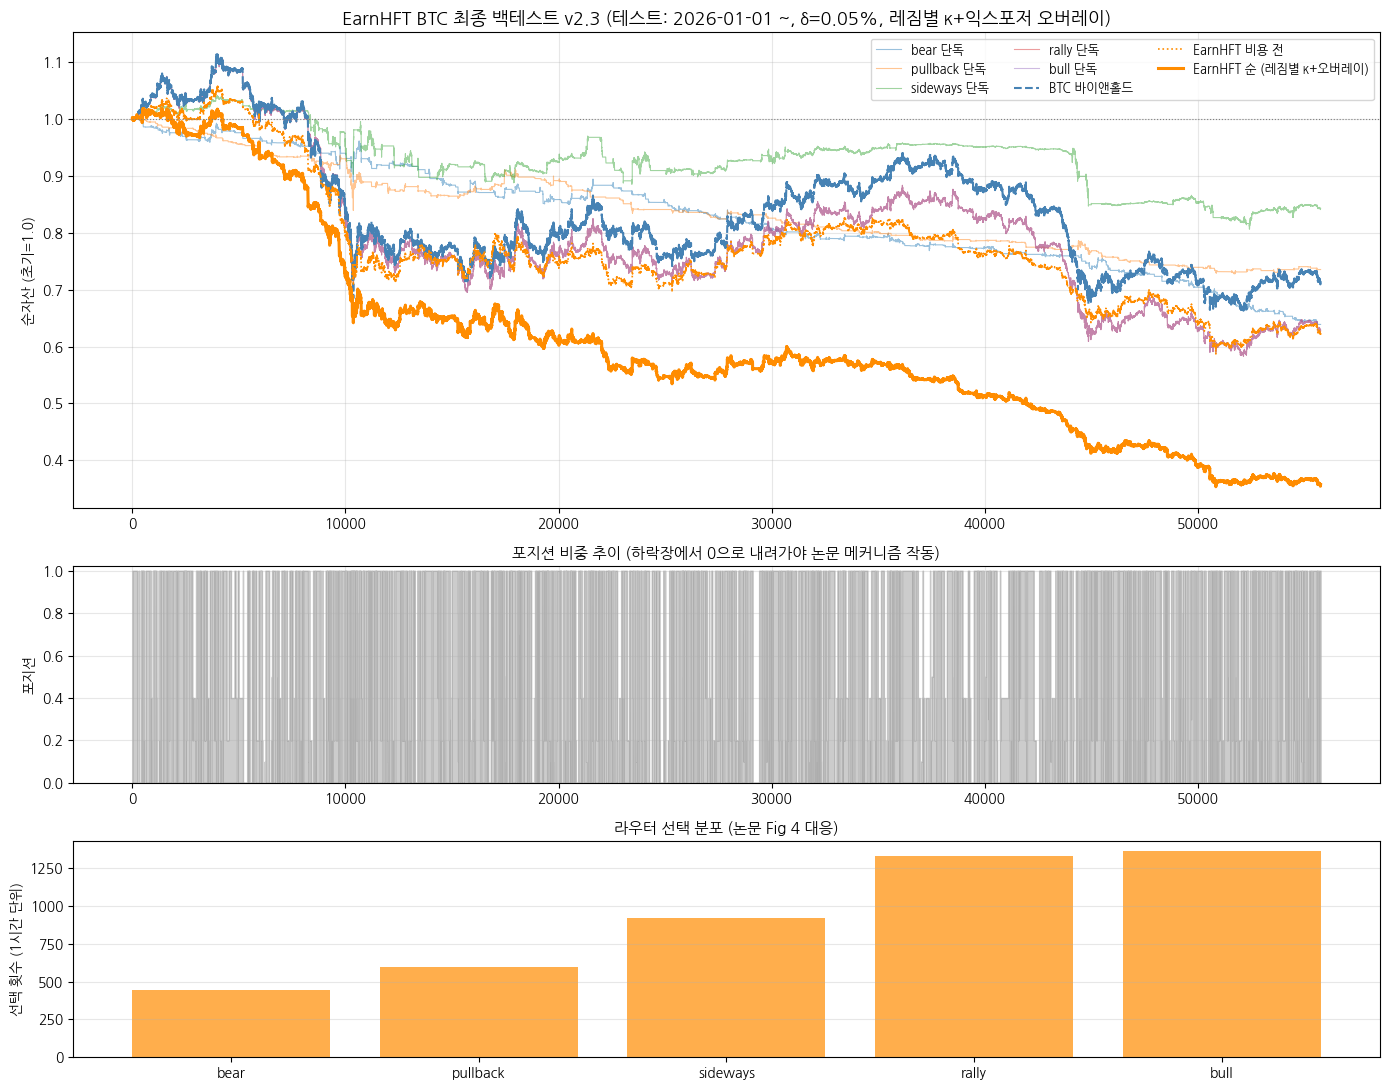

저장: earnhft_btc_backtest.png
CPU times: user 1min 16s, sys: 148 ms, total: 1min 17s
Wall time: 1min 18s


In [9]:
%%time
# 최종 테스트 (2026-01~07) — 복리 NAV, 비용 전/후 분해. κ·풀·라우터 선택은 전부 valid에서 완료
def perf(nav, nav_g=None, poss=None):
    rets = nav[1:] / nav[:-1] - 1
    out = {
        '총수익(순)':    f'{(nav[-1]-1)*100:+.2f}%',
        '총수익(비용전)': f'{(nav_g[-1]-1)*100:+.2f}%' if nav_g is not None else '—',
        '비용드래그':    f'{(nav_g[-1]-nav[-1])*100:.2f}%p' if nav_g is not None else '—',
        '연환산(순)':    f'{(nav[-1] ** (STEPS_PER_YEAR / len(rets)) - 1)*100:+.2f}%',
        'Sharpe':      f'{rets.mean()/(rets.std()+1e-12)*np.sqrt(STEPS_PER_YEAR):.3f}',
        'MDD':         f'{(nav/np.maximum.accumulate(nav)-1).min()*100:.2f}%',
    }
    if poss is not None:
        out['봉당|Δw|'] = f'{np.abs(np.diff(np.concatenate([[0.0], poss]))).mean():.4f}'
        out['평균포지션'] = f'{poss.mean():.2f}'
    return out

results = {}
TE_HI = I_TE1 - 1

# v2.3: 레짐별 κ + 실행 시 익스포저 상한(RISK_CAP_IDX)을 적용한 최종 시스템
nav_r, navg_r, pos_r, chosen = run_system(router_best, I_TE0, TE_HI, cap=True)
results['EarnHFT (레짐별 κ+오버레이)'] = perf(nav_r, navg_r, pos_r)

# 참고: 오버레이 끄면 얼마나 차이나는지 (레짐별 κ는 유지, cap만 비교)
nav_rnc, navg_rnc, pos_rnc, _ = run_system(router_best, I_TE0, TE_HI, cap=False)
results['EarnHFT (오버레이 전, 참고)'] = perf(nav_rnc, navg_rnc, pos_rnc)

# 진단용: 히스테리시스 없는 동작 — κ 효과의 분리 확인 (선택엔 미사용, cap도 미적용)
nav_r0, navg_r0, pos_r0, _ = run_system(router_best, I_TE0, TE_HI, kappa=0.0)
results['EarnHFT (κ=0, 진단)'] = perf(nav_r0, navg_r0, pos_r0)

nav_bh = CLOSE[I_TE0:I_TE0 + len(nav_r)] / CLOSE[I_TE0] * (1 - DELTA)  # 진입 수수료 1회
results['BTC 바이앤홀드'] = perf(nav_bh)

agent_curves = {}
for regime in POOL_REGIMES:
    qtab = q_table(pool_nets[regime], I_TE0, TE_HI)
    nav_a, navg_a, pos_a = rollout_qtab(qtab, I_TE0, I_TE0, TE_HI, KAPPA[regime])
    results[f'{regime} 단독'] = perf(nav_a, navg_a, pos_a)
    agent_curves[regime] = nav_a

sel_counts = pd.Series([POOL_REGIMES[j] for j in chosen]).value_counts()
print('라우터 선택 분포:', sel_counts.to_dict())
print(f'평균 포지션: {pos_r.mean():.2f} | 플랫(=0) 비율: {(pos_r==0).mean()*100:.1f}%\n')

res_df = pd.DataFrame(results).T
print(res_df.to_string())
res_df.to_csv(OUT_DIR / 'earnhft_btc_performance.csv', encoding='utf-8-sig')
print('\n저장: earnhft_btc_performance.csv')
print('참고 — v1(가산 회계·κ 없음): EarnHFT -135%, bear 단독 -232% (비용 드래그 -120~-270%p 역산). '
      '비용 전 알파가 있는데 순수익이 안 나오면 회전 억제(κ↑·학습 δ 부풀리기)가 남은 과제.')

fig, axes = plt.subplots(3, 1, figsize=(14, 11), height_ratios=[2.2, 1, 1], sharex=False)
ax = axes[0]
for regime, cv in agent_curves.items():
    ax.plot(cv, lw=0.8, alpha=0.45, label=f'{regime} 단독')
ax.plot(nav_bh, lw=1.5, ls='--', color='steelblue', label='BTC 바이앤홀드')
ax.plot(navg_r, lw=1.2, ls=':', color='darkorange', label='EarnHFT 비용 전')
ax.plot(nav_r, lw=2.2, color='darkorange', label='EarnHFT 순 (레짐별 κ+오버레이)')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'EarnHFT BTC 최종 백테스트 v2.3 (테스트: {TEST_START} ~, δ={DELTA*100:.2f}%, 레짐별 κ+익스포저 오버레이)', fontsize=13)
ax.set_ylabel('순자산 (초기=1.0)')
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.fill_between(range(len(pos_r)), pos_r, 0, alpha=0.4, color='gray')
ax2.set_title('포지션 비중 추이 (하락장에서 0으로 내려가야 논문 메커니즘 작동)', fontsize=11)
ax2.set_ylabel('포지션')
ax2.set_ylim(0, 1.02)
ax2.grid(alpha=0.3)

ax3 = axes[2]
cnt = sel_counts.reindex(POOL_REGIMES).fillna(0)
ax3.bar(cnt.index, cnt.values, color='darkorange', alpha=0.7)
ax3.set_title('라우터 선택 분포 (논문 Fig 4 대응)', fontsize=11)
ax3.set_ylabel('선택 횟수 (1시간 단위)')
ax3.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'earnhft_btc_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: earnhft_btc_backtest.png')

## 규칙 기반 라우터 베이스라인 (v2.1 → v2.2 경계 재보정)

v2 결과에서 DDQN 라우터가 병목으로 확인됨: valid 전 체크포인트 음수, 테스트 선택 분포 균등(랜덤 수준),
풀 최고 단독보다 큰 폭 열세 — 논문 Fig 3(라우터 ≥ 전 단독)과 반대. 추가로 **동일 코드·시드 재실행에서
DDQN 라우터 테스트 성적이 -14.66% → -22.48%로 이동**(GPU 비결정성) — 라우터 학습이 노이즈 수준이라는 방증.

**대안**: 학습 없는 규칙 라우터 — 매시간 최근 W봉의 가격 기울기(일 환산, 과거만 사용)로 레짐을 판정하고
그 레짐에서 선별된 에이전트에 위임. 판정 창 W ∈ {72, 144, 288, 576}봉만 valid에서 선택.

**v2.2 수정 — 판정 경계 재보정**: v2.1 첫 실행(-31.04%, B&H 이하)의 원인은 경계 스케일 미스매치.
세그먼트 기울기(극점→극점, ±4.4%/일 경계)는 트레일링 W봉 기울기(반전이 섞여 진폭이 작음)와 분포가 달라
하락장 테스트에서도 bear+bull 판정이 6%뿐이었고, 44%를 sideways(평균 포지션 0.92)로 위임해 평균
포지션 0.96으로 폭락을 직격했다. 수정: 경계를 **판정 통계 자체(train 트레일링 W봉 기울기)의 분위수
[0.2, 0.4, 0.6, 0.8]**로 W별 재보정 — 레짐당 train 시간의 ~20%가 보장되고, valid/test에서도 13~24%로 분포.

**판정**: 재보정 규칙 라우터가 DDQN 라우터를 이기면 → 병목은 라우팅 학습(규칙 라우터 채택).
여전히 나쁘면 → 풀 에이전트의 레짐 일반화 한계 (bear 에이전트가 test에서 포지션 0.81을 잡는 등
"레짐 라벨 ≠ 실제 행동" 문제) — 학습 δ 부풀리기 재학습으로 이동.


**v2.3 추가 (2026-07-20)**: v2.2 결과(규칙 -15.61% > DDQN -22.48%로 필요조건은 넘었지만 절대수익은
여전히 마이너스)를 보고 세 가지를 더했다 — ① Stage II 선별(코드셀6)에 익스포저 페널티, ② κ를 레짐별로
독립 선택, ③ 여기(규칙 라우터)와 DDQN 라우터(코드셀9) 양쪽 실행부에만 적용되는 레짐별 포지션 상한
(`RISK_CAP_IDX`) — bear 진입 시 최대 20%, pullback 40%로 하드캡. 학습 루프(코드셀5 Stage II, 코드셀8
라우터)에는 적용하지 않아 "학습은 전권, 실행은 관성" 원칙(44종목 트랙 교훈)을 유지했다. β도 -150을
추가해(코드셀1) bear/pullback 후보 자체의 방어성을 높였다.

In [ ]:
%%time
# 규칙 기반 라우터 (v2.5) — 트레일링 기울기 레짐 판정 → 해당 레짐 에이전트에 위임 (레짐별 κ + 익스포저 오버레이 적용)
# v2.1 버그 수정(유지): 판정 경계를 세그먼트 기울기 분위수가 아니라 "판정 통계 자체"(train 트레일링 W봉 기울기)의
# 분위수로 W별 재보정 — 분포 스케일 미스매치 제거.
# v2.3 추가: κ가 레짐별 dict가 됐고(KAPPA), RISK_CAP_IDX로 bear/pullback 진입 시 포지션을 하드캡(코드셀 1 정의).
# v2.5 추가: held-out test=2024(강세장)에서 B&H 대비 -94%p, 비용 드래그 45.54%p로 확인된 원인 —
# 레짐 판정 자체가 매시간 다시 계산돼 눌림목마다 계속 전환됨(강세장인데도 5개 레짐에 거의 고르게 분산).
# κ가 "포지션 레벨"에서 하던 히스테리시스를 "레짐 판정 레벨"에도 적용 — 전환하려면 직전 전환 이후 최소
# min_dwell 시간(라우팅 스텝 단위)은 지나야 함. W·min_dwell 둘 다 valid에서 선택 (테스트 미접촉).
assert 'perf' in globals() and 'nav_r' in globals(), '코드셀 9(최종 테스트)를 먼저 실행하세요'

def trailing_bounds(window):
    """train 구간 트레일링 window봉 기울기(일 환산)의 [0.2,0.4,0.6,0.8] 분위수 → 레짐당 train의 ~20% 보장"""
    sl = (CLOSE[I_TR0 + window:I_TR1] / CLOSE[I_TR0:I_TR1 - window] - 1) / (window / 288)
    return np.quantile(sl, [0.2, 0.4, 0.6, 0.8])

def run_rule_router(qtabs, base, i0, i1, window, bounds, kappa, min_dwell=0, p0=0):
    """매 ROUTE_BARS마다 최근 window봉 기울기(과거만 사용)를 bounds로 레짐 판정 → 해당 에이전트의 Q로 실행.
    kappa: 스칼라 또는 레짐별 dict. 레짐이 RISK_CAP_IDX에 있으면 실행 시 포지션 상한을 강제(익스포저 오버레이).
    min_dwell: 레짐 전환 최소 유지 시간(라우팅 스텝=시간 단위) — 직전 전환 이후 이만큼 지나야 재전환 허용.
    기본값 0 = 제약 없음(기존과 동일 동작, 매시간 자유롭게 전환)."""
    p, cur, dwell = p0, None, 0
    navs, navs_g, poss, chosen = [1.0], [1.0], [], []
    for k, t in enumerate(range(i0, i1)):
        if k % ROUTE_BARS == 0:
            sl = (CLOSE[t] / CLOSE[t - window] - 1) / (window / 288)
            new_regime = REGIMES[int(np.digitize(sl, bounds))]
            if cur is None:
                cur, dwell = new_regime, 0
            elif new_regime != cur and dwell >= min_dwell:
                cur, dwell = new_regime, 0
            else:
                dwell += 1
            chosen.append(cur)
        q = qtabs[cur][t - base, p]
        a = int(q.argmax())
        kap = kappa[cur] if isinstance(kappa, dict) else kappa
        if a != p and q[a] - q[p] <= kap:
            a = p
        cap = RISK_CAP_IDX.get(cur)
        if cap is not None:
            a = min(a, cap)
        g = POS_FRACS[a] * (CLOSE[t + 1] / CLOSE[t] - 1)
        navs_g.append(navs_g[-1] * (1 + g))
        navs.append(navs[-1] * (1 + g - TRADE_COST_MAT[p, a]))
        poss.append(POS_FRACS[a])
        p = a
    return np.array(navs), np.array(navs_g), np.array(poss), chosen

# ── 판정 창 W × 최소 유지시간 min_dwell 공동 스윕 (valid만 사용, 경계는 W별 train 재보정) ──
qtabs_va = {r: q_table(pool_nets[r], I_VA0, I_VA1 - 1) for r in POOL_REGIMES}
W_CANDIDATES = [72, 144, 288, 576]
DWELL_CANDIDATES = [0, 2, 4, 8, 16, 24]  # 라우팅 스텝(=시간) 단위

print('판정 창 W × 최소 유지시간 dwell 스윕 (valid | 참고: DDQN 라우터는 위 최종 테스트 셀 출력):')
sweep_scores, sweep_bounds = {}, {}
for w in W_CANDIDATES:
    b = trailing_bounds(w)
    for md in DWELL_CANDIDATES:
        nav, nav_g, _, ch = run_rule_router(qtabs_va, I_VA0, I_VA0, I_VA1 - 1, w, b, KAPPA, md)
        n_switch = sum(1 for i in range(1, len(ch)) if ch[i] != ch[i - 1])
        sweep_scores[(w, md)] = nav[-1]
        sweep_bounds[(w, md)] = b
        print(f'  W={w:>3}봉({w//12:>2}h) dwell={md:>2}h: valid 순 {(nav[-1]-1)*100:+.2f}% | '
              f'비용 전 {(nav_g[-1]-1)*100:+.2f}% | 전환 {n_switch}회')
W_RULE, MIN_DWELL = max(sweep_scores, key=sweep_scores.get)
w_bounds = {W_RULE: sweep_bounds[(W_RULE, MIN_DWELL)]}
print(f'▶ 선택된 W = {W_RULE}봉, min_dwell = {MIN_DWELL}h (valid {(sweep_scores[(W_RULE, MIN_DWELL)]-1)*100:+.2f}%)')

# ── 테스트 1회 실행 + DDQN 라우터·B&H 비교 ──
qtabs_te = {r: q_table(pool_nets[r], I_TE0, TE_HI) for r in POOL_REGIMES}
nav_rr, navg_rr, pos_rr, ch_rr = run_rule_router(qtabs_te, I_TE0, I_TE0, TE_HI, W_RULE, w_bounds[W_RULE], KAPPA, MIN_DWELL)

cmp_df = pd.DataFrame({
    f'규칙 라우터 v2.5 (W={W_RULE}, dwell={MIN_DWELL}h, 레짐별 κ+오버레이)': perf(nav_rr, navg_rr, pos_rr),
    'DDQN 라우터 (레짐별 κ+오버레이)': perf(nav_r, navg_r, pos_r),
    'BTC 바이앤홀드': perf(nav_bh),
}).T
print('\n' + cmp_df.to_string())
print('\n테스트 레짐 판정 분포:', pd.Series(ch_rr).value_counts().to_dict())
n_switch_te = sum(1 for i in range(1, len(ch_rr)) if ch_rr[i] != ch_rr[i - 1])
print(f'테스트 구간 레짐 전환 횟수: {n_switch_te}회 (참고: v2.3 dwell=0 기준 대비 비교용)')
print(f'플랫(=0) 비율: {(pos_rr==0).mean()*100:.1f}% (DDQN 라우터 {(pos_r==0).mean()*100:.1f}%)')
print('참고 — v2.1(세그먼트 경계, 미스매치): 규칙 라우터 -31.04%, bear+bull 판정 6%, 평균 포지션 0.96')
print('참고 — v2.2(경계 재보정, 오버레이 전): 규칙 라우터 -15.61%, DDQN -22.48%')
print('참고 — v2.4(dwell 없음, κ 전역): 규칙 라우터 -7.62%/+3.95%, held-out test=2024 +26.78%(B&H +120.60%)')
cmp_df.to_csv(OUT_DIR / 'earnhft_btc_rule_router.csv', encoding='utf-8-sig')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
ax = axes[0]
ax.plot(nav_bh, lw=1.2, ls='--', color='steelblue', label='BTC 바이앤홀드')
ax.plot(nav_r, lw=1.2, color='gray', label='DDQN 라우터')
ax.plot(navg_rr, lw=1.0, ls=':', color='darkorange', label='규칙 라우터 비용 전')
ax.plot(nav_rr, lw=2.0, color='darkorange', label=f'규칙 라우터 순 (W={W_RULE}, dwell={MIN_DWELL}h)')
ax.axhline(1, color='gray', lw=0.8, ls=':')
ax.set_title(f'규칙 기반 라우터 v2.5 vs DDQN 라우터 (테스트 {TEST_START}~, δ={DELTA*100:.2f}%, dwell={MIN_DWELL}h)')
ax.set_ylabel('순자산 (초기=1.0)')
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.3)
ax2 = axes[1]
ax2.fill_between(range(len(pos_rr)), pos_rr, 0, alpha=0.4, color='darkorange')
ax2.set_title('규칙 라우터 포지션 추이 (하락 레짐에서 0으로 내려가는지)', fontsize=11)
ax2.set_ylabel('포지션')
ax2.set_ylim(0, 1.02)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'earnhft_btc_rule_router.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: earnhft_btc_rule_router.csv / earnhft_btc_rule_router.png')

## 국면 강건성 체크 (in-train sanity check, 재학습 없음)

지금까지 valid(2025 Q4)·test(2026 상반기)가 전부 하락장이라, "방어적으로 튜닝하니 잘 됐다"가
진짜 알파인지 장세가 우연히 맞아떨어진 건지 구분이 안 됐다. 이 셀은 학습된 pool·κ·W를 그대로 재사용해
(재학습 없음, q_table만 새로 계산) **성격이 다른 구간**에서 규칙 라우터가 말이 되게 행동하는지 확인한다.

**주의 — 이건 진짜 held-out 검증이 아니다**: 아래 구간은 전부 train(2021-01~2025-09) 안에 있어서
Stage II 학습이 청크 샘플링으로 이미 이 가격 데이터를 봤다. 여기서 잘 나온다고 진짜 일반화를 증명하는
건 아니고, 반대로 여기서도 크게 깨지면 "밸리드 구간에만 맞춰진 우연"이라는 강한 반증이 된다 — 즉
비대칭적 증거(나쁘면 확실히 문제, 좋아도 약한 신호)로만 쓸 것. 진짜 깨끗한 검증을 하려면 train 컷오프를
앞으로 당겨(예: 2023-06까지만) Stage II부터 새로 학습해야 한다(별도 재작업, ~20분).

- 2022년: BTC -63% (완만하고 꾸준한 약세장 — test와 다른 유형의 하락)
- 2023년: BTC +129% (등락 심한 횡보/회복)
- 2024년: BTC +128% (뚜렷한 강세장)

In [ ]:
%%time
# 국면 강건성 체크 — 학습된 pool_nets·KAPPA·W_RULE·RISK_CAP_IDX 그대로 재사용, q_table만 새 구간에 대해 계산
OOS_WINDOWS = [
    ('2022 약세장 (BTC -63%)', '2022-01-01', '2022-12-31'),
    ('2023 횡보/회복 (BTC +129%)', '2023-01-01', '2023-12-31'),
    ('2024 강세장 (BTC +128%)', '2024-01-01', '2024-12-31'),
]

oos_rows = {}
for name, s, e in OOS_WINDOWS:
    i0 = ts_idx(pd.Timestamp(s))
    i1 = min(ts_idx(pd.Timestamp(e) + pd.Timedelta(days=1)), I_TR1) - 1
    qtabs_oos = {r: q_table(pool_nets[r], i0, i1) for r in POOL_REGIMES}
    nav_o, navg_o, pos_o, ch_o = run_rule_router(qtabs_oos, i0, i0, i1, W_RULE, w_bounds[W_RULE], KAPPA, MIN_DWELL)
    nav_bh_o = CLOSE[i0:i0 + len(nav_o)] / CLOSE[i0] * (1 - DELTA)
    oos_rows[f'{name} — 규칙 라우터'] = perf(nav_o, navg_o, pos_o)
    oos_rows[f'{name} — B&H'] = perf(nav_bh_o)
    print(f'{name}: 판정 분포 {pd.Series(ch_o).value_counts().to_dict()}')

oos_df = pd.DataFrame(oos_rows).T
print()
print(oos_df.to_string())
oos_df.to_csv(OUT_DIR / 'earnhft_btc_oos_regime_check.csv', encoding='utf-8-sig')
print('\n저장: earnhft_btc_oos_regime_check.csv')
print('참고: in-train 구간이라 진짜 held-out 검증은 아님 — 위 마크다운 캐비어트 참고.')

## 진짜 held-out 검증 (train 컷오프 재분할, 2024년 강세장 = 완전 미접촉 test)

앞의 "국면 강건성 체크"는 train 안의 구간이라 Stage II가 이미 본 데이터였다 — 참고용 sanity check일
뿐 진짜 검증이 아니었다. 이번엔 제대로 한다: **train 컷오프를 2023-06-30으로 당겨서 2024년 전체
(강세장, BTC +128%)를 Stage II·선별·규칙 라우터 튜닝 어디에도 전혀 노출되지 않은 진짜 test로 만들고**,
그 분할로 Stage II부터 처음부터 재학습해 규칙 라우터를 다시 검증한다.

- train: 2021-01 ~ 2023-06 (Stage II를 이 구간만으로 처음부터 재학습, β 5개 동일)
- valid: 2023-07 ~ 2023-12 (등락 심한 횡보/회복 — W·κ·후보 선별은 여기서만)
- test: 2024-01 ~ 2024-12 (강세장, **완전 미접촉**) — 여기서 딱 한 번만 평가

DDQN 라우터는 여러 버전에 걸쳐 신뢰 못 할 걸로 이미 결론났으므로 재검증 대상에서 제외하고, 채택하기로
한 **규칙 라우터만** 이 새 분할로 재검증한다. 원래 실행 결과(test=2026-01~07)를 덮어쓰지 않도록 모든
분할 의존 변수는 `_B` 접미사·별도 모델 경로(`earnhft_btc_holdout/`)로 분리했고, 마지막 셀에서 원래
분할로 복원한다 — 이 섹션을 실행한 뒤에도 위쪽 셀들을 다시 실행하면 원래 결과가 그대로 재현된다.

예상 소요: Stage II 재학습 ~14분 + 선별 ~1분 + 규칙 라우터 W스윕·테스트 ~2분, 총 ~17분.

In [12]:
# ── held-out 분할 재정의: 원래 분할 값을 백업한 뒤 새 분할로 전역 변수를 덮어쓴다 ──
assert 'run_rule_router' in globals() and 'perf' in globals(), '코드셀 10(규칙 라우터)까지 먼저 실행하세요'
_ORIG_SPLIT = dict(
    TRAIN_END=TRAIN_END, VALID_START=VALID_START, VALID_END=VALID_END, TEST_START=TEST_START,
    I_TR0=I_TR0, I_TR1=I_TR1, I_VA0=I_VA0, I_VA1=I_VA1, I_TE0=I_TE0, I_TE1=I_TE1,
    FEAT_T=FEAT_T, MEX_T=MEX_T, MODEL_DIR=MODEL_DIR,
    CHUNK_STARTS=CHUNK_STARTS, CHUNK_RETS=CHUNK_RETS, _PDF=_PDF,
)

TRAIN_END, VALID_START, VALID_END, TEST_START = '2023-06-30', '2023-07-01', '2023-12-31', '2024-01-01'
TEST_END_B = '2024-12-31'

I_TR0, I_TR1 = 0, ts_idx(pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1))
I_VA0, I_VA1 = ts_idx(VALID_START), ts_idx(pd.Timestamp(VALID_END) + pd.Timedelta(days=1))
I_TE0, I_TE1 = ts_idx(TEST_START), ts_idx(pd.Timestamp(TEST_END_B) + pd.Timedelta(days=1))

# z-score도 새 train 구간 통계로 다시 계산 (원래 test=2026 통계가 새 test=2024 구간에 섞여 들어가면 안 됨)
mu, sd = feat.iloc[I_TR0:I_TR1].mean(), feat.iloc[I_TR0:I_TR1].std() + 1e-8
FEAT = ((feat - mu) / sd).clip(-5, 5).values.astype(np.float32)
FEAT_T = torch.from_numpy(FEAT).to(DEVICE)
mmu, msd = mex.iloc[I_TR0:I_TR1].mean(), mex.iloc[I_TR0:I_TR1].std() + 1e-8
MEX = ((mex - mmu) / msd).clip(-5, 5).fillna(0.0).values.astype(np.float32)
MEX_T = torch.from_numpy(MEX).to(DEVICE)

CHUNK_STARTS = np.arange(I_TR0, I_TR1 - CHUNK_LEN, CHUNK_LEN)
CHUNK_RETS = CLOSE[CHUNK_STARTS + CHUNK_LEN] / CLOSE[CHUNK_STARTS] - 1
_kde = gaussian_kde(CHUNK_RETS)
_PDF = np.maximum(_kde(CHUNK_RETS), 1e-8)

MODEL_DIR = _ORIG_SPLIT['MODEL_DIR'].parent / 'earnhft_btc_holdout'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'[held-out] train {pd.Timestamp(DT[I_TR0])} ~ {pd.Timestamp(DT[I_TR1-1])}')
print(f'[held-out] valid {pd.Timestamp(DT[I_VA0])} ~ {pd.Timestamp(DT[I_VA1-1])}')
print(f'[held-out] test  {pd.Timestamp(DT[I_TE0])} ~ {pd.Timestamp(DT[I_TE1-1])} (2024 강세장, 완전 미접촉)')
print(f'[held-out] 학습 청크 {len(CHUNK_STARTS)}개 | 모델 저장 경로: {MODEL_DIR}')

[held-out] train 2021-01-02 04:55:00 ~ 2023-06-30 23:55:00
[held-out] valid 2023-07-01 00:00:00 ~ 2023-12-31 23:55:00
[held-out] test  2024-01-01 00:00:00 ~ 2024-12-31 23:55:00 (2024 강세장, 완전 미접촉)
[held-out] 학습 청크 909개 | 모델 저장 경로: /content/drive/MyDrive/졸업프로젝트/models/earnhft_btc_holdout


In [ ]:
%%time
# Stage II 재학습 (held-out 분할, β·에폭 구성은 원래와 동일) — candidate_paths_B로 별도 보관
# 세션 재접속 등으로 이 분할 후보가 이미 Drive(MODEL_DIR=earnhft_btc_holdout/)에 있으면 재학습 없이 재사용
_existing_B = sorted(MODEL_DIR.glob('btc_beta*_ep*.pt'))
if len(_existing_B) >= len(BETAS) * EPOCHS:
    candidate_paths_B = {}
    for pth in _existing_B:
        b, e = pth.stem.replace('btc_beta', '').split('_ep')
        candidate_paths_B[(int(b), int(e))] = pth
    print(f'[held-out] 디스크에서 후보 {len(candidate_paths_B)}개 재사용 (재학습 건너뜀)')
else:
    candidate_paths_B = {}
    for beta in BETAS:
        print(f'\n=== [held-out] β={beta} DDQN 학습 ({EPOCHS}에폭 × {CHUNKS_PER_EPOCH}청크) ===')
        t0 = time.time()
        for i, pth in enumerate(train_agent(beta)):
            candidate_paths_B[(beta, i + 1)] = pth
        print(f'β={beta} 완료 ({(time.time() - t0) / 60:.1f}분)')
    print(f'\n[held-out] 후보 총 {len(candidate_paths_B)}개')

In [14]:
%%time
# Stage II 선별 (held-out 분할) — 코드셀6과 동일 로직(레짐 분할·κ 전역 선택·익스포저 페널티), 결과는 _B로 분리
tr_close = CLOSE[I_TR0:I_TR1]
SLOPE_BOUNDS_B = np.quantile(seg_slopes(tr_close, find_segments(tr_close)), [0.2, 0.4, 0.6, 0.8])

va_close = CLOSE[I_VA0:I_VA1]
va_segs_B = [(s + I_VA0, e + I_VA0) for s, e in find_segments(va_close)]
va_labels_B = [REGIMES[int(np.digitize(sl, SLOPE_BOUNDS_B))] for sl in seg_slopes(CLOSE, va_segs_B)]
print(f'[held-out] valid 세그먼트 {len(va_segs_B)}개 | 분포: {pd.Series(va_labels_B).value_counts().to_dict()}')

VA_HI_B = I_VA1 - 1
rows_B = {}
for (beta, ep), pth in sorted(candidate_paths_B.items()):
    net = QNet(OBS_LO, N_POS).to(DEVICE)
    net.load_state_dict(torch.load(pth, map_location=DEVICE))
    qtab = q_table(net, I_VA0, VA_HI_B)
    for kappa in KAPPAS:
        per, poss_all = {}, []
        for (s, e), lab in zip(va_segs_B, va_labels_B):
            nav, _, poss = rollout_qtab(qtab, I_VA0, s, min(e, VA_HI_B), kappa)
            per.setdefault(lab, []).append(nav[-1] - 1)
            poss_all.append(poss)
        pos_cat = np.concatenate(poss_all)
        row = {lab: float(np.mean(v)) for lab, v in per.items()}
        row['avg_pos'] = float(pos_cat.mean())
        row['turnover'] = float(np.abs(np.diff(np.concatenate([[0.0], pos_cat]))).mean())
        rows_B[(kappa, beta, ep)] = row

perf_mat_B = pd.DataFrame(rows_B).T
perf_mat_B.index.names = ['kappa', 'beta', 'epoch']
perf_mat_B.to_csv(DATA_DIR / 'earnhft_btc_kappa_sweep_holdout.csv', encoding='utf-8-sig')

# v2.4와 동일하게 κ는 전역으로만 선택 (레짐별 독립 선택은 얇은 세그먼트에 과적합돼 실패했던 전례가 있음)
kappa_scores_B = {}
for kappa in KAPPAS:
    sub = perf_mat_B.loc[kappa]
    bests = [sub[r].max() for r in REGIMES if r in sub.columns]
    kappa_scores_B[kappa] = float(np.mean(bests))
KAPPA_GLOBAL_B = max(kappa_scores_B, key=kappa_scores_B.get)
KAPPA_B = {r: KAPPA_GLOBAL_B for r in REGIMES}
print(f'[held-out] 선택된 κ(전역) = {KAPPA_GLOBAL_B}')

pool_nets_B, sel_rows_B = {}, []
for regime in REGIMES:
    sub = perf_mat_B.loc[KAPPA_B[regime]]
    if regime not in sub.columns:
        continue
    lam = EXPOSURE_LAMBDA.get(regime, 0.0)
    score = sub[regime].astype(float) - lam * sub['avg_pos'].astype(float)
    bk = score.idxmax()
    net = QNet(OBS_LO, N_POS).to(DEVICE)
    net.load_state_dict(torch.load(candidate_paths_B[bk], map_location=DEVICE))
    pool_nets_B[regime] = net
    torch.save(net.state_dict(), MODEL_DIR / f'btc_pool_{regime}.pt')
    sel_rows_B.append({'regime': regime, 'beta': bk[0], 'epoch': bk[1], 'kappa': KAPPA_B[regime],
                        'valid_ret': float(sub.loc[[bk], regime].iloc[0]),
                        'avg_pos': float(sub.loc[[bk], 'avg_pos'].iloc[0])})
    print(f'[held-out] {regime}: β={bk[0]} ep{bk[1]} κ={KAPPA_B[regime]} '
          f'(valid {sel_rows_B[-1]["valid_ret"]*100:+.2f}%, 평균포지션 {sel_rows_B[-1]["avg_pos"]:.2f})')

POOL_REGIMES_B = list(pool_nets_B.keys())
pd.DataFrame(sel_rows_B).to_csv(DATA_DIR / 'earnhft_btc_pool_selection_holdout.csv', index=False, encoding='utf-8-sig')
print(f'[held-out] 풀 {len(pool_nets_B)}개 구성 완료')

[held-out] valid 세그먼트 1069개 | 분포: {'sideways': 409, 'rally': 249, 'pullback': 240, 'bull': 89, 'bear': 82}
[held-out] 선택된 κ(전역) = 1.0
[held-out] bear: β=-150 ep1 κ=1.0 (valid +0.06%, 평균포지션 0.00)
[held-out] pullback: β=-90 ep1 κ=1.0 (valid +0.00%, 평균포지션 0.00)
[held-out] sideways: β=100 ep3 κ=1.0 (valid +0.02%, 평균포지션 0.20)
[held-out] rally: β=-10 ep7 κ=1.0 (valid +0.33%, 평균포지션 0.84)
[held-out] bull: β=-10 ep3 κ=1.0 (valid +1.63%, 평균포지션 0.83)
[held-out] 풀 5개 구성 완료
CPU times: user 1min 5s, sys: 111 ms, total: 1min 5s
Wall time: 1min 6s


In [ ]:
%%time
# 규칙 라우터 재검증 (held-out) — W×dwell을 새 valid(2023H2)에서 선택, 새 test(2024)는 딱 한 번 평가
qtabs_va_B = {r: q_table(pool_nets_B[r], I_VA0, I_VA1 - 1) for r in POOL_REGIMES_B}
sweep_scores_B, sweep_bounds_B = {}, {}
print('[held-out] 판정 창 W × 최소 유지시간 dwell 스윕 (valid=2023H2):')
for w in W_CANDIDATES:
    b = trailing_bounds(w)
    for md in DWELL_CANDIDATES:
        nav, nav_g, _, ch = run_rule_router(qtabs_va_B, I_VA0, I_VA0, I_VA1 - 1, w, b, KAPPA_B, md)
        n_switch = sum(1 for i in range(1, len(ch)) if ch[i] != ch[i - 1])
        sweep_scores_B[(w, md)] = nav[-1]
        sweep_bounds_B[(w, md)] = b
        print(f'  W={w:>3}봉({w//12:>2}h) dwell={md:>2}h: valid 순 {(nav[-1]-1)*100:+.2f}% | 전환 {n_switch}회')
W_RULE_B, MIN_DWELL_B = max(sweep_scores_B, key=sweep_scores_B.get)
w_bounds_B = {W_RULE_B: sweep_bounds_B[(W_RULE_B, MIN_DWELL_B)]}
print(f'▶ 선택된 W = {W_RULE_B}봉, min_dwell = {MIN_DWELL_B}h (valid {(sweep_scores_B[(W_RULE_B, MIN_DWELL_B)]-1)*100:+.2f}%)')

TE_HI_B = I_TE1 - 1
qtabs_te_B = {r: q_table(pool_nets_B[r], I_TE0, TE_HI_B) for r in POOL_REGIMES_B}
nav_B, navg_B, pos_B, ch_B = run_rule_router(qtabs_te_B, I_TE0, I_TE0, TE_HI_B, W_RULE_B, w_bounds_B[W_RULE_B], KAPPA_B, MIN_DWELL_B)
nav_bh_B = CLOSE[I_TE0:I_TE0 + len(nav_B)] / CLOSE[I_TE0] * (1 - DELTA)

cmp_df_B = pd.DataFrame({
    f'규칙 라우터 (held-out test=2024, W={W_RULE_B}, dwell={MIN_DWELL_B}h)': perf(nav_B, navg_B, pos_B),
    'BTC 바이앤홀드 (2024)': perf(nav_bh_B),
}).T
print('\n[held-out — 진짜 미접촉 test 2024, 강세장] 결과:')
print(cmp_df_B.to_string())
print('\n레짐 판정 분포:', pd.Series(ch_B).value_counts().to_dict())
n_switch_te_B = sum(1 for i in range(1, len(ch_B)) if ch_B[i] != ch_B[i - 1])
print(f'테스트 구간 레짐 전환 횟수: {n_switch_te_B}회')
print('참고 — v2.4(dwell 없음): held-out test=2024 +26.78%(비용 전 +72.32%, 비용드래그 45.54%p, B&H +120.60%)')
cmp_df_B.to_csv(DATA_DIR / 'earnhft_btc_holdout_test2024.csv', encoding='utf-8-sig')
print('\n저장: earnhft_btc_holdout_test2024.csv')
print('참고: 이 test=2024 구간은 Stage II 학습·선별·W·dwell 튜닝 어디에도 노출된 적 없음 — 진짜 held-out 결과.')

In [16]:
# ── 원래 분할(test=2026-01~07)로 복원 — 이후 위쪽 셀을 다시 실행해도 안전 ──
TRAIN_END, VALID_START, VALID_END, TEST_START = (
    _ORIG_SPLIT['TRAIN_END'], _ORIG_SPLIT['VALID_START'], _ORIG_SPLIT['VALID_END'], _ORIG_SPLIT['TEST_START'])
I_TR0, I_TR1 = _ORIG_SPLIT['I_TR0'], _ORIG_SPLIT['I_TR1']
I_VA0, I_VA1 = _ORIG_SPLIT['I_VA0'], _ORIG_SPLIT['I_VA1']
I_TE0, I_TE1 = _ORIG_SPLIT['I_TE0'], _ORIG_SPLIT['I_TE1']
FEAT_T, MEX_T = _ORIG_SPLIT['FEAT_T'], _ORIG_SPLIT['MEX_T']
MODEL_DIR = _ORIG_SPLIT['MODEL_DIR']
CHUNK_STARTS, CHUNK_RETS, _PDF = _ORIG_SPLIT['CHUNK_STARTS'], _ORIG_SPLIT['CHUNK_RETS'], _ORIG_SPLIT['_PDF']
print('원래 분할(test=2026-01~07)로 복원 완료 — pool_nets/KAPPA/W_RULE 등 원래 결과는 그대로 살아있음')

원래 분할(test=2026-01~07)로 복원 완료 — pool_nets/KAPPA/W_RULE 등 원래 결과는 그대로 살아있음


## 결과 판정 체크리스트 / 한계 (v2.1)

**v2 실행 결과 요약 (2026-07-19, PROGRESS.md §8 상세)**
- EarnHFT 순 -14.66% / 비용 전 -7.58% / MDD -28.96% — B&H(-28.50%, MDD -40.49%) 대비 +13.8%p, MDD 축소
- κ=0 진단 -98.21% → κ 히스테리시스 기여 +83%p. 비용 전 알파 존재(+21%p vs B&H) 확인
- 다양성 통과, 풀 5개 전부 고유. **잔여 병목 = DDQN 라우터** (valid 전 체크포인트 음수, 선택 분포 랜덤 수준)
- pullback 단독 +8.05%는 왕복 몇 회 수준 관측치 + valid 0% → 전략으로 인용 금지

**코드셀 10 (규칙 라우터) 판정**
1. 규칙 라우터 ≫ DDQN 라우터면: 병목은 라우팅 학습 — 보고서에 "레짐 위임은 유효하나 DDQN 라우터
   학습이 실패(선택→보상 연결 희미)"로 정리하고 규칙 라우터를 최종 시스템으로 채택.
2. 규칙 라우터도 비슷하게 나쁘면: 풀 에이전트의 레짐 일반화 한계 — 학습 δ 부풀리기 재학습으로 이동.
3. 순수익 플러스 전환 여부와 무관하게, B&H 대비 초과 + MDD 축소가 유지되는지 확인.

**한계 (보고서 명시)**
- 슬리피지·스프레드 미모델링 (수수료 δ만 반영), 5분봉 종가 체결 가정
- 롱 온리 (논문도 현물 기준 동일) — 하락장 방어는 포지션 0이 상한
- 후보 40개(논문 200개), 단일 시드 — 시드 민감도 미검증
- κ 히스테리시스·규칙 라우터는 논문에 없는 장치 — 5분봉·0.05% 이식에 필요했던 수정으로 명시
- valid(2025 Q4)가 급락 국면에 치우침 → 선별이 방어형 에이전트를 선호할 수 있음 (레짐별 선별로 완화)

**다음 단계 후보**
- 규칙 라우터로도 부족하면: 학습 δ 부풀리기(2~4배)로 Q\* 자체를 저회전화한 Stage II 재학습,
  또는 N_POS 11→5 축소 (둘 다 **코드셀 5** 재실행 필요, ~10분)
- δ 민감도 스윕 (0 / 0.02% / 0.05%) — 논문 조건(0.02%) 재현 여부 확인, 보고서 소재
- 성공 시: `crypto/live_trading_loop_binance.py`에 EarnHFTPolicyAdapter 구현 (5분 주기, 라우터 1시간 주기, κ 포함)
- 보고서: 44종목 트랙(v1~v3)과 BTC 트랙을 "포트폴리오 vs 단일자산" 비교 구도로 정리
